# Penalty-Weight Pareto Optimization

**Gate X · 70 runs, 63 distinct pulses · 45 OFAT (15 configs × seeds 42/43/44) + 25 grid · `maxiter = 1500`**

Choosing the four soft-penalty weights in the GRAPE cost function of
`core.optimizer.optimize_multi_state_pulse`: sweep them, score every candidate on a metric
training never sees, and select under a hardware spectral-width budget.

---

## Executive summary

| | |
|---|---|
| **Recommended under $W_{99} \leq 70\%$ of each drive's own mask** | $\lambda_{\mathrm{deriv}} = 10^{-6}$, other weights at incumbent |
| **Held-out $F$** | **0.999236** (incumbent: 0.997753) |
| **99% occupied width $W_{99}$** | cavity **46.6%** of 54 MHz · transmon **58.8%** of 66 MHz (incumbent: 41.5% · 47.8%) |
| **Trade** | $+1.5\times10^{-3}$ fidelity for $+5.1$ pts cavity, $+11.0$ pts transmon |

Five qualifications, each developed below and none of them cosmetic:

1. **$\lambda_{\mathrm{deriv}}$ is the only axis that matters** (§7.1, §7.4). It moves held-out
   $F$ by $1.04\times10^{-2}$ and is the only effect confirmed real under seed replication
   (paired $t(2) = -12.0$ on a 10× positive control). $\lambda_{\mathrm{boundary}}$'s apparent
   $6.4\times10^{-4}$ movement is *smaller* than one point's own across-seed noise
   ($1.3\times10^{-3}$) and is unidentified, not weak. $\lambda_{\mathrm{disc}}$'s
   $\sim\!10^{-3}$, non-monotonic swing **is** that same noise floor (§7.4).
   $\lambda_{\mathrm{amp}}$ moves it by **exactly zero** (§7.2).
2. **No run converged** (§5). All 45 hit the `maxiter` cap. The fidelity *ranking* is stable
   under continuation; occupied width was still drifting.
3. **The budget verdict rests on convergence, not on the metric** (§10.5). The scored cost is the
   **99% occupied width** $W_{99}$ (the narrowest window carrying 99% of the drive power),
   charged **per drive against that drive's own band mask**, with the budget at 70% of each.
4. **Three seeds separate signal from noise, but not every claim** (§7.4). $\lambda_{\mathrm{deriv}}$'s effect clears a paired $t(2) = -12.0$; the recommendation wins on all three seeds but its margin over incumbent does not clear the 5% bar ($t(2) = +2.9$).
5. **The recommendation survives more data, not just more seeds** (§12, §13, §15). A
   costlier two-phase training protocol (cold+warm-start, ~1.8–1.82x the wall-clock per
   config) was tried across both the OFAT ladder and the grid corner: 14 of 15 configs score
   marginally higher, but only the single largest delta clears the $\sim\!10^{-3}$ noise
   floor, so it is not adopted (§13.3). Pooling every trial ever run in the campaign — 150,
   across both protocols — and taking the single best individual (not seed-averaged) run
   turns up the *same* recipe as the recommendation, $3.85\times10^{-4}$ above its seed mean:
   inside the noise floor, not a better config (§15). Separately, a cheap 500-iteration
   mid-training screen was validated as a shortlisting tool for future sweeps ($\rho =
   0.88$–$0.94$; top-3 and eventual winner agree with the final ranking on both
   snapshot-carrying seeds, §12) — useful going forward, not a factor in this recommendation.

**Reading order.** §1 says why the weights need tuning at all and why the constraint is an
occupied-width cap; §2 is the method; §3–§11 are the study; §12 validates a cheap
mid-training screen for future sweeps; §13 tests a costlier two-phase training protocol and
finds it not worth adopting; §14 lists what this run cannot settle; §15 pools every trial run
across the campaign and checks whether the single best individual draw beats the
recommendation (it doesn't, once noise is accounted for).

# 1. Rationale

### 1.1 Why the weights cannot be tuned on the training objective

The cost function that trains every logical-gate pulse in this project is a fidelity plus four
penalty terms:

$$\mathcal{C}(u) \;=\; -\,\overline{F_{\mathrm{coh}}}(u)
\;+\; \lambda_{\mathrm{disc}}\!\!\sum_{i\neq j}\!(F_i-F_j)^2
\;+\; \lambda_{\mathrm{deriv}}\, g_d(u)
\;+\; \lambda_{\mathrm{boundary}}\, g_b(u)
\;+\; \lambda_{\mathrm{amp}}\, g_a(u)$$

Every $\lambda$ term is a **regularizer**: non-negative, and able only to *raise* the cost.
Tuning the weights against the training objective therefore has exactly one fixed point: all
four at zero. The optimizer obliges, and returns a pulse that is rougher, wider in bandwidth, and
better at exploiting the finite Hilbert space it trained in. The training number goes up; the
pulse gets worse.

So the weights cannot be chosen by optimizing the quantity they appear in. They have to be chosen
against something training never sees. This notebook does that in three steps: **sweep** the
weights, **score** each candidate on the reported fidelity at held-out cavity truncations, then
**select** under a hardware spectral-width budget.

### 1.2 What each penalty term buys

| term | definition (`core/grape_core.py`) | what it suppresses |
|---|---|---|
| $g_d$ | $\sum_k \lVert u_{k+1}-u_k\rVert^2$ | step-to-step roughness, hence high-frequency content |
| $g_b$ | $\lVert u_0\rVert^2 + \lVert u_{N-1}\rVert^2$ | a discontinuous switch-on/off at the pulse edges |
| $g_a$ | $\sum \max(0, \lvert u\rvert - \epsilon_{\max})^2$ | drive amplitude above a soft cap $\epsilon_{\max}$ |
| disc | $\sum_{i\neq j}(F_i-F_j)^2$ over `trunc_list` | fidelity that depends on where the Hilbert space is cut |

The first three are **shape** penalties on the waveform; the fourth is a **robustness** penalty on
the solution. Only the fourth touches the physics of the target; the rest are hardware realism.

### 1.3 Training objective vs. reported metric

The distinction that runs through the whole notebook:

- $F_{\mathrm{coh}}$: the coherent process fidelity the optimizer actually descends on, averaged
  over the training truncations $n_c \in \{22, 24, 26\}$ (Heeres Supp. Eq. 23). Returned by
  `optimize_multi_state_pulse` as `F_coh_train`.
- $F_{\mathrm{held}}$: the gate fidelity (Pedersen 2007 average-gate-fidelity formula),
  computed from the full $D \times D$ propagator, projected onto the logical subspace
  ($\texttt{logical\_block} = B^\dagger U B$), and evaluated at truncations the pulse never
  trained on. Produced by `main.report_pedersen_gate_fidelity`. **This is the headline
  number.**

Throughout this notebook, $F_{\mathrm{held}}$ will be referred to simply as **F**, **F_held**, or
**mean F_held** (depending on context), not "Pedersen fidelity." **F_coh** refers only
to the training objective above.

Their difference is `overfit_gap`. Ranking on $F_{\mathrm{coh}}$ would reward exploitation of the
truncation wall, which is the failure mode the penalties exist to prevent. So it cannot be the
selection metric.

### 1.4 Why the constraint is an occupied-width cap

Bandwidth appears nowhere in $\mathcal{C}(u)$. Three separate mechanisms act on the spectrum, and
only the first two are inside the optimizer:

| # | mechanism | where it acts | what it constrains |
|---|---|---|---|
| 1 | penalties $g_d, g_b, g_a$, plus an L-BFGS-B box on the raw variable | inside the cost | waveform shape and amplitude |
| 2 | hard band-limit projection, $\pm27$ MHz cavity / $\pm33$ MHz transmon | `core.fourier_cutoff.project_bandlimit`, applied to $u$ **and** the gradient every iteration | spectral **support**: power is exactly zero outside the band |
| 3 | `occ99_frac` $\leq 0.70$, i.e. $W_{99} \leq 70\%$ of **each drive's own** mask (37.8 MHz cavity, 46.2 MHz transmon) | `pv.recommend`, after training | spectral **concentration**: how tightly the power packs inside the band |

Rows 2 and 3 are both per-drive and they are not the same limit. Row 2 is **hard**: it is where
power is allowed to exist at all, it is enforced by `project_bandlimit` on the controls *and* the
gradient at every iteration, and no choice of penalty weights can violate it. Row 3 is **soft**:
it is how much of that allowance a converged pulse actually consumes, it is checked only after
training, and it is the line a configuration can fail. Two limits, two roles, same per-drive
granularity: a drive that is allowed 54 MHz is budgeted against 54 MHz.

**The metric.** For each complex drive $\epsilon_C = u_0 + iu_1$ and $\epsilon_T = u_2 + iu_3$,
`analysis.penalty_sweep.pulse_metrics` computes the **99% occupied width**: the narrowest
frequency window carrying 99% of the power,

$$W_{99} \;=\; \min_{[a,b]}\,(b-a) \quad\text{subject to}\quad
\sum_{a \le f \le b} p(f) \;\ge\; 0.99,
\qquad p(f) = \frac{\lvert\hat\epsilon(f)\rvert^2}{\sum_{f'}\lvert\hat\epsilon(f')\rvert^2},$$

with $f = \texttt{np.fft.fftfreq}(N, \mathrm{d}t)$ in MHz. Dividing by the total power makes it
amplitude-independent: scaling a pulse by $10\times$ leaves it unchanged. The window edges land on
FFT bins, so $W_{99}$ is quantised to $1/(N\,\mathrm{d}t) = 0.909$ MHz. They are also reported
(`occ99_{cav,tra}_{lo,hi}_MHz`), because *where* in the allowed band the power sits is a separate
fact from how wide it is. See Table 1.

**Each drive is charged against its own allowance.** The scored scalar is

$$\texttt{occ99\_frac} \;=\; \max\!\left(\frac{W_{99}^{C}}{54\ \mathrm{MHz}},\;
\frac{W_{99}^{T}}{66\ \mathrm{MHz}}\right),$$

the share of its own allowance consumed by the worse drive. Taking `max` of the two *raw* widths
instead would be a conjunction of two constraints forced to share one threshold, and the drives do
not share an allowance: the cavity mask is $\pm27$ MHz and the transmon's $\pm33$. They are also
separate hardware chains (own LO, mixer, DAC channel, line), so nothing physically experiences the
max of the two. Comparing their raw widths is comparing "20 GB used" on a 50 GB disk against
"25 GB used" on a 100 GB disk. Normalising first restores the correct conjunction,

$$\max(x/a,\, y/b) \leq t \quad\Longleftrightarrow\quad (x \leq ta) \;\wedge\; (y \leq tb),$$

and leaves the budget a dimensionless percentage, which is one fewer thing that can be mis-ported.
§10.3 shows the case where this changes which reason a configuration is rejected for.

**Why mechanism 3 is not redundant with mechanism 2.** The mask is a 0/1 indicator. It says where
power is *allowed*, not how it is arranged, and an orthogonal projection cannot express a
preference: "flat out to the band edge" and "tightly clustered near DC" are equally admissible.
The spectral *support* is already pinned exactly by the mask, so mechanism 3 charges for how that
allowance is used, not whether it is exceeded. The cell below measures both pulses at the centre
of this study: the one the budget accepts and the one it rejects.

In [1]:
# Table 1. Spectral anatomy of the two pulses at the centre of the study.
# Self-contained on purpose: Section 1 precedes the Setup cell, so this must not
# depend on GATE / dt / pv. `core.fourier_cutoff` is numpy-only -- do NOT import
# `analysis.penalty_sweep` here (it pulls in `main`, which calls matplotlib.use("Agg")).
import os, sys
import numpy as np
import pandas as pd

if os.path.abspath(".") not in sys.path:
    sys.path.insert(0, os.path.abspath("."))
from core.fourier_cutoff import make_band_mask

DT = 0.002                                  # us
EDGE = {"cav": 27.0, "tra": 33.0}           # FIXED["cav_band"] / ["tra_band"]
BAND = {d: 2 * e for d, e in EDGE.items()}  # mask WIDTHS: 54 cav / 66 tra
BUDGET_FRAC = 0.70                          # of each drive's OWN mask
CHI_MHz = -2.194                            # core.grape_core.chi / 2pi
CACHE = "results/penalty_sweep_cache/X"
PAIR = {"deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5": "incumbent (deriv=1e-5)",
        "deriv=0_boundary=2e-05_amp=8e-05_disc=0.5":     "control   (deriv=0)"}

ofat = pd.read_csv("tables/penalty_sweep_X_ofat.csv").drop_duplicates("label").set_index("label")


def occ_width(P, f, frac=0.99):
    """Narrowest window holding `frac` of the power, as (width, lo, hi).

    Mirrors `analysis.penalty_sweep.occupied_width`; duplicated rather than
    imported to keep this cell import-light (see the note above)."""
    o = np.argsort(f)                                  # fftfreq is not monotonic
    fs, c = f[o], np.cumsum(P[o] / P.sum())
    b = np.searchsorted(c, np.concatenate(([0.0], c[:-1])) + frac, side="left")
    ok = np.nonzero(b < c.size)[0]
    i = ok[np.argmin(fs[b[ok]] - fs[ok])]
    return fs[b[i]] - fs[i], fs[i], fs[b[i]]


def anatomy(eps, edge):
    """The 99% occupied width and window, and the power outside the band mask."""
    f = np.fft.fftfreq(len(eps), d=DT)                 # cycles/us == MHz
    P = np.abs(np.fft.fft(eps)) ** 2
    P /= P.sum()
    w99, lo, hi = occ_width(P, f)
    return dict(w99=w99, lo=lo, hi=hi,
                outside=P[~make_band_mask(len(eps), DT, -edge, edge)].sum())


hdr = f"{'':28s}{'W99':>6}{'of mask':>9}{'window':>17}{'outside':>9}"
print(hdr)
for label, name in PAIR.items():
    path = f"{CACHE}/u_{ofat.loc[label, 'config_hash']}.npy"
    if not os.path.exists(path):
        print(f"{name}: pulse cache absent -- regenerate with "
              f"`python analysis/penalty_sweep.py --gate X --mode ofat --seeds 42 --maxiter 1500`")
        continue
    u = np.load(path)
    for drive, (i, j) in (("cav", (0, 1)), ("tra", (2, 3))):
        a = anatomy(u[:, i] + 1j * u[:, j], EDGE[drive])
        # Each drive's width is charged against ITS OWN mask, not the wider one.
        print(f"{name + ' ' + drive:28s}{a['w99']:6.2f}{a['w99']/BAND[drive]:9.1%}"
              f"  [{a['lo']:6.2f},{a['hi']:6.2f}]{a['outside']:9.1e}")
    r = ofat.loc[label]
    print(f"{'':28s}recorded occ99_frac = {r['occ99_frac']:.1%} "
          f"(binding: {r['binding_drive']}; occ99_MHz = {r['occ99_MHz']:.2f}, "
          f"n_bar_drive = {r['n_bar_drive']:.2f})")

print(f"\nbudget: each drive may occupy at most {BUDGET_FRAC:.0%} of its OWN mask")
print(f"        -> {BUDGET_FRAC*BAND['cav']:.1f} MHz cavity (of {BAND['cav']:.0f}), "
      f"{BUDGET_FRAC*BAND['tra']:.1f} MHz transmon (of {BAND['tra']:.0f}).")
print(f"        W99 is bounded above by the mask width by construction, so the fraction is a\n"
      f"        genuine share of the attainable range rather than a number on an open scale.")


                               W99  of mask           window  outside
incumbent (deriv=1e-5) cav   25.45    47.1%  [-13.64, 11.82]  6.5e-32
incumbent (deriv=1e-5) tra   33.64    51.0%  [-25.45,  8.18]  6.5e-32
                            recorded occ99_frac = 51.0% (binding: tra; occ99_MHz = 33.64, n_bar_drive = 2.04)
control   (deriv=0) cav      42.73    79.1%  [-24.55, 18.18]  6.8e-32
control   (deriv=0) tra      61.82    93.7%  [-32.73, 29.09]  7.0e-32
                            recorded occ99_frac = 93.7% (binding: tra; occ99_MHz = 61.82, n_bar_drive = 5.49)

budget: each drive may occupy at most 70% of its OWN mask
        -> 37.8 MHz cavity (of 54), 46.2 MHz transmon (of 66).
        W99 is bounded above by the mask width by construction, so the fraction is a
        genuine share of the attainable range rather than a number on an open scale.


**Table 1. Spectral anatomy of the accepted and the rejected pulse.** Per drive: the 99%
occupied width $W_{99}$, that width as a share of the drive's own band mask, the window achieving
it, and the power fraction outside the hard band mask. The two configurations differ only in
$\lambda_{\mathrm{deriv}}$ ($10^{-5}$ vs. $0$).

Two things follow.

**The mask genuinely cannot do this job.** Both pulses leak $\sim\!10^{-31}$ of their power
outside the band (the projection is exact) and both occupy the band out to its last bin.
Mechanism 2 sees two identical pulses. Mechanism 3 sees a transmon drive at 51.0% of its
allowance against one at 93.7%. That difference is the entire object of this study.

**The window edges say something the width does not.** Both transmon drives are wide, but the
incumbent's 99% window is $[-25.5, +8.2]$ (pushed hard against the lower mask edge, consistent
with the $\bar n \approx 2$ number-split peak it is addressing), while the control's is
$[-32.7, +29.1]$, filling the mask almost symmetrically. Same statistic, different spectral
strategy; only the edges distinguish them.

**$\lambda_{\mathrm{deriv}}$ is the in-cost proxy for bandwidth, and an imperfect one.** By
Parseval, $g_d = \sum_k \lVert u_{k+1}-u_k\rVert^2$ equals a sum over frequency of
$\lvert\hat u(f)\rvert^2$ weighted by $4\sin^2(\pi f\,\mathrm{d}t)$: a power-weighted,
frequency-dependent penalty, not a width. The smoothness penalty *is* a bandwidth penalty in
disguise, which is why §7.1 finds it carrying the entire observed spread in occupied width. But
because it weights by power, the optimizer can lower $g_d$ by making the pulse *weaker* rather
than *narrower*, while $W_{99}$ divides total power out and is blind to that trade. The two
decouple. Width has to be measured separately from the term meant to control it.

**Why a constraint and not a fifth penalty term.** A hardware bandwidth limit is a *threshold*,
not a preference: below it nothing is gained by going lower, above it the pulse is unusable.
Folding it into $\mathcal{C}(u)$ would require an exchange rate between fidelity and MHz that
nobody can quote, and would change the cost function every pulse in `pulses/` was trained under,
breaking comparability. Keeping it outside also lets the budget move after the fact: §10.5
re-selects across the whole range with no retraining.

# 2. Methodology

### 2.1 Fixed conditions

Only the four penalty weights vary. Everything else is pinned in `analysis.penalty_sweep.FIXED`
and forms part of the configuration hash, so changing any of it invalidates the cache rather than
silently mixing regimes.

| | value |
|---|---|
| training truncations | `trunc_list = [22, 24, 26]`, `n_t = 3` |
| pulse | $N = 550$ steps at $\mathrm{d}t = 2$ ns (1.1 µs total), 4 controls |
| hard frequency bands | cavity $\pm27$ MHz, transmon $\pm33$ MHz |
| amplitude | `hard_amp_limit = 40` rad/µs (box), $\epsilon_{\max} = 40$ rad/µs (soft cap) |
| warm start | smooth random, seeded per run |
| incumbent recipe `BASELINE` | deriv $10^{-5}$ · boundary $2\times10^{-5}$ · amp $8\times10^{-5}$ · disc $0.5$ |

The **incumbent** is `main.py`'s production default: the recipe every pulse in
`pulses/u_*_main.npy` was trained under. It is the status quo this study tries to beat, and it
appears throughout as a dotted line or an open diamond.

### 2.2 Search design

Two modes, 45 trained rows in total:

- **OFAT ladder** (20 rows). One axis at a time over `BASELINE[name] * (0, 0.1, 0.3, 1, 3, 10)`,
  the other three held at the incumbent. The $\times 0$ rung is a deliberate negative control
  (§8). The fourth axis is the amplitude **threshold**
  $\epsilon_{\max} \in \{12, 16, 20, 28, 40\}$ rad/µs rather than the weight
  $\lambda_{\mathrm{amp}}$. §7.2 shows why the weight cannot do anything.
- **Focused 2-D grid** (25 rows). $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$,
  five literal values on each axis, to test for interaction between the two axes that measurably
  move the pulse.

The designs overlap where a grid value coincides with an OFAT rung, so the 45 rows resolve to
**38 distinct trained pulses** (seven rows are exact cache hits) over **36 distinct recipes**:
the remaining two pairs differ only in the sixteenth digit, which §7.3 turns into a noise
measurement.

### 2.3 Training

Each configuration calls `core.optimizer.optimize_multi_state_pulse`, minimizing $\mathcal{C}(u)$
averaged over the three training truncations (joblib-parallel across them) with L-BFGS-B for at
most 1500 iterations. The band-limit projection is applied *inside* the objective, to both the
controls and the gradient, so the search never leaves the band-limited subspace and mechanism 2
of §1.4 cannot be violated by any choice of weights. `converged` in the output CSV is scipy's
`success` flag. §5 audits it.

### 2.4 Scoring

Scoring is independent of training and never re-optimizes.

- **Fidelity.** `main.report_pedersen_gate_fidelity` builds the full propagator for the saved
  pulse, projects it onto the logical subspace, and returns F_held, the gate fidelity defined in
  §1.3. Evaluated
  at $n_c = 16, 18, \ldots, 40$; the ten values outside `trunc_list` form the **held-out** set.
- **Fidelity columns.** `F_ped_heldout_mean` (headline), `F_ped_heldout_min` (worst-case
  truncation), `robustness_spread` ($\max - \min$ across the held-out set), `overfit_gap`,
  `leakage_L1_mean` / `_max`.
- **Pulse-cost columns.** `occ99_frac` (§1.4, the scored one) with its per-drive parts
  `occ99_frac_{cav,tra}` and `binding_drive`; `peak_amp`; `roughness` (RMS first difference,
  rad/µs). Reported but never scored: the same widths in MHz (`occ99_MHz`,
  `occ99_{cav,tra}_MHz`) and their window edges `occ99_{cav,tra}_{lo,hi}_MHz`, plus `n_bar_drive`.

Held-out truncations are a **scoring** set only. They enter no gradient, which is why widening
them cannot make $\lambda_{\mathrm{disc}}$ bite (§7.2).

### 2.5 Reproduction

```bash
python analysis/penalty_sweep.py --gate X --mode ofat --seeds 42 --maxiter 1500
python analysis/penalty_sweep.py --gate X --mode grid --grid-x deriv --grid-y boundary \
       --seeds 42 --maxiter 1500
python analysis/penalty_convergence_check.py --gate X --seed 42 --extra 750   # Section 5
# then run this notebook top to bottom with RUN_SWEEP = False
```

Trained pulses and scored rows are disk-cached under `results/penalty_sweep_cache/`, keyed by a
hash of the full configuration (gate, weights, seed, `maxiter`, and all of `FIXED`). An
interrupted sweep resumes without retraining, and re-scoring never re-optimizes. The production
run was 10.6 h wall-clock, ~1000 s per pulse.

### 2.6 A second protocol: two-phase training

Everything above (§2.1-2.5) describes one continuous L-BFGS-B run, `trunc_list=[22,24,26]`,
`maxiter=1500`. `analysis.penalty_sweep.TWO_PHASE` defines an alternative, used for a later
retrain of the OFAT ladder (5 seeds: 42-46) and the 3x3 grid corner (3 seeds: 42-44) --
**phase 1**: cold start, `trunc_list=[22,26]`, `maxiter=1000`; **phase 2**: warm-started from
phase 1's output pulse, `trunc_list=[26]` only, `maxiter=1500`. Selected via
`--protocol two_phase` (default remains the single continuous run above); `protocol` enters
`_config_hash` only when it is not `"single_phase"`, so the two protocols occupy disjoint
cache/hash spaces and neither run can silently reuse or overwrite the other's pulses.

One consequence worth stating plainly: the **trained-truncation set differs**. Under the
protocol above, `trunc_list=[22,24,26]` means $n_c=24$ is trained; under two-phase, the
trained set is the union of both phases, $\{22,26\}$, so $n_c=24$ is **held-out** instead.
`score_pulse` is called with the correct trained set per protocol, so `F_ped_heldout_mean`
stays an apples-to-apples "fidelity on truncations this pulse never trained on" statistic
either way -- it just means the held-out set itself isn't identical between the two.

**Cost.** Measured directly from `train_time_s` on every freshly-trained (non-cache-hit) row
(§13.3 recomputes this live):

| | n fresh trains | mean wall time |
|---|---|---|
| single-phase OFAT | 45 | 1164.7 s (19.4 min) |
| single-phase grid | 25 | 956.4 s (15.9 min) |
| two-phase OFAT | 75 | 2120.0 s (35.3 min) |
| two-phase grid | 27 | 1682.8 s (28.0 min) |

**Two-phase costs about 1.8x more per config than single-phase**, not less -- despite doing
*less* nominal work by a naive iteration times truncation count (single-phase:
$1500 \times 3 = 4500$ trunc-iterations; two-phase: $1000\times2 + 1500\times1 = 3500$, about
78% as much). The reason is parallelism, not line-search cost -- see below.
Stated here as a measured finding, not explained away: whatever "lightweight" the protocol's
name might suggest, the wall-clock says otherwise.

**Why.** `optimize_multi_state_pulse` evaluates every truncation in `trunc_list` as a
joblib `Parallel(n_jobs=3)` job, one worker per truncation, on *every* L-BFGS-B iteration
(`core/optimizer.py`). Wall-clock per iteration is set by the slowest worker, not the sum,
and per-truncation cost grows with $n_c$ (larger Hilbert space -> larger eigendecomposition),
so $n_c=26$ is always the bottleneck. Single-phase's other two truncations ($n_c=22,24$)
therefore ride along nearly free -- their workers finish early and idle while $n_c=26$'s
finishes -- so 1500 iterations cost $\approx 1500\times\text{cost}(26)$. Two-phase pays for
$n_c=26$ in both phases: phase 1's 1000 iterations (2-way parallel with $n_c=22$, still
bottlenecked by 26) plus phase 2's 1500 iterations, where $n_c=26$ is now the *only*
truncation, so there is no free ride left -- $\approx(1000+1500)\times\text{cost}(26) =
2500\times\text{cost}(26)$. That predicts a $2500/1500\approx1.67\times$ ratio, close to
the $1.8\times$ measured above (the remainder plausibly parallel-pool overhead amortized
over fewer truncations, or run-to-run noise from the sharded training job). The naive
trunc-iteration count above is the wrong cost model under this parallelization scheme -- it
treats each truncation's cost as additive, when under `n_jobs`-wide parallelism they are
concurrent against a shared bottleneck instead.

**Outcome.** §13.2 (Table 15, Figure 5) compares the two protocols on the 9 grid-corner
cells: mean delta $+7.87\times10^{-4}$ (two-phase minus single-phase), range
$[+1.09,+18.8]\times10^{-4}$, against a within-two-phase seed spread up to
$9.88\times10^{-4}$. §13.3 (new) runs the same comparison on the 15 OFAT configs: 14 of 15
score higher under two-phase, mean delta $+3.39\times10^{-4}$, range
$[-4.05, +10.7]\times10^{-4}$ -- only the single largest case clears the campaign's
established $\sim\!10^{-3}$ noise floor (§7.4's `floor_basin`). Neither protocol reaches
genuine scipy convergence for the overwhelming majority of runs (§5.1's finding holds for
both); two-phase's phase-2 convergence flag/iteration count is the only one recorded in the
row schema, phase 1's is not surfaced separately. Read together: two-phase is **consistent
with a mild fidelity improvement, not established as one** at this seed count, and it costs
meaningfully more to get it -- the same "is this signal or floor" caution §7.4 applies
everywhere else in this document applies here too.

**Which data belongs to which protocol.** Every downstream table/figure in this notebook
traces to exactly one of these sources; `combined` is the only place two protocols coexist,
and only because the 9 grid-corner cells are fully *replaced*, never *blended*, with their
two-phase counterparts (§9's opening note in the "Loading the sweep" cell):

| table / variable | protocol | seeds | feeds |
|---|---|---|---|
| `penalty_sweep_X_ofat.csv` / `df` | single-phase | 42,43,44 | Figure 1; `combined`'s OFAT rows (Figure 3, §10, §11) |
| `penalty_sweep_X_grid_deriv_boundary.csv` / `grid` | single-phase | 42 | Figure 2 (untouched); outer 16 cells of `combined` (Figure 3) |
| `penalty_sweep_X_grid_deriv_boundary_3x3_two_phase.csv` / `grid3x3_2` | two-phase | 42,43,44 | Figure 5; inner 9-cell corner of `combined` (Figure 3) |
| `penalty_sweep_X_ofat_two_phase.csv` / `df2` | two-phase | 42,43,44,45,46 | §15/Figure 6 (`all_trials`) and the best-trial search only -- not Figure 1 or Figure 3 |
| `penalty_sweep_X_disc_null.csv` / `disc_null` | single-phase | 42 | Figure 4 only; excluded from every ranking |
| `combined` (derived) | mixed by design | -- | Figure 3, §10 recommendation, §11 summary table |
| `all_trials` (derived, §15) | pooled, unaggregated | -- | Figure 6 and `find_best_trial` only |

# 3. Setup

`RUN_SWEEP = False` loads the completed CSVs; set it to `True` only to retrain (~10.6 h). Every
pulse is disk-cached, so a resumed run is cheap.

`%matplotlib inline` must come **after** the imports: `analysis.penalty_sweep` imports `main`,
which calls `matplotlib.use("Agg")` at module scope and would otherwise render every figure below
as a text repr.

In [2]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import visualization.penalty_viz as pv
from analysis.penalty_sweep import (
    BASELINE, FIXED, PENALTY_NAMES, AXIS_NAMES, BAND_LIMITS_MHz, GRID_VALUES,
)

# NOTE: must come AFTER the imports above. `analysis.penalty_sweep` imports `main`,
# which calls matplotlib.use("Agg") at module scope -- that would silently override
# the inline backend and every figure below would render as a text repr.
%matplotlib inline
print("matplotlib backend:", matplotlib.get_backend())

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- knobs -------------------------------------------------------------
RUN_SWEEP   = False   # True = retrain (~10.7 h); False = load the saved CSVs
GATE        = "X"
# The spectral budget is a PERCENTAGE OF EACH DRIVE'S OWN BAND MASK, not a bare
# number of MHz. The two drives have different allowances (54 vs 66 MHz) and are
# separate hardware chains, so a single MHz threshold shared between them is a
# category error; a dimensionless fraction also cannot be silently ported to a
# statistic on another scale (see pv's module docstring and
# validation/test_pulse_metrics.py::PerDriveAllowanceTest).
BUDGET_FRAC = pv.BUDGET_FRAC        # 0.70 of each drive's own mask
COST_METRIC = pv.DEFAULT_COST       # "occ99_frac"
COST_BUDGET = pv.DEFAULT_MAX_COST   # 0.70, dimensionless
SEEDS       = [42]
MAXITER     = 1500
# -----------------------------------------------------------------------

print("incumbent recipe :", BASELINE)
print("sweep axes       :", AXIS_NAMES)
print("trained truncs   :", FIXED["trunc_list"])
print("bands (MHz)      :", FIXED["cav_band"], FIXED["tra_band"])
print(f"spectral budget  : {COST_METRIC} <= {COST_BUDGET:.0%} of each drive's own mask")
for drive, width in BAND_LIMITS_MHz.items():
    print(f"   -> {drive}: {COST_BUDGET * width:.1f} MHz of {width:.0f} MHz allowed")

matplotlib backend: module://matplotlib_inline.backend_inline
incumbent recipe : {'deriv': 1e-05, 'boundary': 2e-05, 'amp': 8e-05, 'disc': 0.5}
sweep axes       : ('deriv', 'boundary', 'amp_max')
trained truncs   : [22, 24, 26]
bands (MHz)      : (-27.0, 27.0) (-33.0, 33.0)
spectral budget  : occ99_frac <= 70% of each drive's own mask
   -> cav: 37.8 MHz of 54 MHz allowed
   -> tra: 46.2 MHz of 66 MHz allowed


In [3]:
def load_sweep(stem):
    """
    Load one sweep table, preferring the full run and falling back to any
    bounded artifact so the notebook still renders mid-campaign.

    The fallbacks are `--tag`ged partial runs (`*_demo`, `*_smoke`), which are
    trained at a much lower `maxiter` -- they are there so the figures render,
    not so their numbers can be quoted.
    """
    for suffix in ("", "_demo", "_smoke"):
        path = f"tables/{stem}{suffix}.csv"
        if os.path.exists(path):
            frame = pd.read_csv(path)
            print(f"loaded {path}: {len(frame)} rows, maxiter={sorted(frame.maxiter.unique())}")
            return frame
    raise FileNotFoundError(f"no CSV for {stem}; run analysis/penalty_sweep.py first")


if RUN_SWEEP:
    raise RuntimeError(
        "RUN_SWEEP=True retrains from scratch. Do it from the shell, not here, so "
        "the shards can run concurrently:\n"
        "  for i in 0 1 2; do python analysis/penalty_sweep.py --gate X "
        "--seeds 42 43 44 --shard $i/3 & done; wait\n"
        "  python analysis/penalty_sweep.py --gate X --seeds 42 43 44 --merge"
    )

df   = load_sweep(f"penalty_sweep_{GATE}_ofat")
grid = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary")

# The retired lambda_disc ladder, kept as a separate artifact because it is a
# calibrated NULL experiment rather than a sweep axis (Section 7.2). It is not
# concatenated into `combined`: it must never enter a ranking or a Pareto front.
disc_null = load_sweep(f"penalty_sweep_{GATE}_disc_null")

# The 3x3 low-lambda_deriv corner, retrained under the new two-phase protocol
# (phase 1: cold start, trunc_list=[22,26], maxiter=1000; phase 2: warm-started
# from phase 1, trunc_list=[26], maxiter=1500 -- see analysis.penalty_sweep.
# TWO_PHASE) on all 3 seeds (42,43,44), not just seed 42. Distinct config_hash
# space from the single-phase tables above -- `protocol` is part of the hash --
# so this is genuinely new, independently-measured data, not a cache hit.
grid3x3_2 = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary_3x3_two_phase")

# Upgrade `grid`'s low-lambda_deriv corner in place: drop the single-seed,
# single-phase rows for the 9 cells GRID_VALUES already covers, and replace them
# with the 3-seed, two-phase rows just loaded. The other 16 5x5-only cells (and
# every OFAT row) are untouched -- Figure 1, Figure 2, and every number quoted in
# Sections 1-14 above keep reading `df`/`grid` and are unaffected by this.
import itertools
corner = set(itertools.product(GRID_VALUES["deriv"], GRID_VALUES["boundary"]))
grid_without_corner = grid[
    ~grid.apply(lambda r: (r.lambda_deriv, r.lambda_boundary) in corner, axis=1)
]
grid_upgraded = pd.concat([grid_without_corner, grid3x3_2], ignore_index=True)

print(f"grid corner upgrade: {len(grid) - len(grid_without_corner)} single-phase "
      f"row(s) dropped, {len(grid3x3_2)} two-phase row(s) added "
      f"({grid3x3_2.seed.nunique()} seeds)")

# One frame for anything that ranks across the whole study (Pareto front,
# recommendation, summary table). `swept` still distinguishes the two designs:
# OFAT rows carry an axis name, grid rows carry "derivxboundary". `combined`
# now carries the upgraded (2-phase, 3-seed) corner -- if the recommendation
# below (Section 10) ever shifts to a grid config as a result, that is this
# cell's doing; check `rec['label']` against the pre-upgrade pick if so.
combined = pd.concat([df, grid_upgraded], ignore_index=True)

print(f"\ncombined: {len(combined)} rows, "
      f"{combined.config_hash.nunique()} distinct trained pulses, "
      f"{combined.label.nunique()} distinct recipes")
combined.head()

loaded tables/penalty_sweep_X_ofat.csv: 45 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_grid_deriv_boundary.csv: 25 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_disc_null.csv: 6 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_grid_deriv_boundary_3x3_two_phase.csv: 27 rows, maxiter=[np.int64(2500)]
grid corner upgrade: 9 single-phase row(s) dropped, 27 two-phase row(s) added (3 seeds)

combined: 88 rows, 86 distinct trained pulses, 31 distinct recipes


,gate,label,swept,multiplier,is_baseline,seed,maxiter,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_coh_train,iterations,converged,train_time_s,F_ped_heldout_mean,F_ped_heldout_min,F_ped_heldout_std,robustness_spread,F_ped_trained_mean,leakage_L1_mean,leakage_L1_max,overfit_gap,peak_amp,roughness,bandwidth_MHz,bandwidth_cav_MHz,bandwidth_tra_MHz,config_hash,...,occ99_cav_MHz,occ99_tra_MHz,sigma_f_MHz,sigma_f_cav_MHz,sigma_f_tra_MHz,centroid_cav_MHz,centroid_tra_MHz,n_bar_drive,occ99_frac,occ99_frac_cav,occ99_frac_tra,binding_drive,occ99_cav_lo_MHz,occ99_cav_hi_MHz,occ99_tra_lo_MHz,occ99_tra_hi_MHz,band_limit_cav_MHz,band_limit_tra_MHz,F_ped_heldout_mean@500,F_ped_heldout_min@500,robustness_spread@500,occ99_frac@500,F_ped_heldout_mean@1000,F_ped_heldout_min@1000,robustness_spread@1000,occ99_frac@1000,protocol,phase1_maxiter,phase2_maxiter,phase1_F_coh_train
0,X,deriv=0_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.0,False,42,1500,0.000000,0.00002,0.00008,0.5,40.0,0.999865,1500,False,830.342962,0.999343,0.995571,0.001280,0.004294,0.999858,0.000657,0.004427,0.000515,35.225146,3.162515,16.904023,9.857525,16.904023,651a62fe533443d4,...,42.727273,61.818182,11.852052,9.857183,11.852052,0.082047,-12.053001,5.493619,0.936639,0.791246,0.936639,tra,-24.545455,18.181818,-32.727273,29.090909,54.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,deriv=0_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.0,False,43,1500,0.000000,0.00002,0.00008,0.5,40.0,0.999886,1500,False,1256.643532,0.999737,0.998604,0.000381,0.001282,0.999883,0.000263,0.001396,0.000145,34.502347,2.361647,14.220085,8.852725,14.220085,3e9fd1fb1859fd3f,...,42.727273,39.090909,9.530730,8.384226,9.530730,-2.841742,-10.553483,4.810156,0.791246,0.791246,0.592287,cav,-25.454545,17.272727,-32.727273,6.363636,54.0,66.0,0.999363,0.999103,0.000293,0.673401,0.999730,0.999232,0.000566,0.774411,NaN,NaN,NaN,NaN
2,X,deriv=0_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.0,False,44,1500,0.000000,0.00002,0.00008,0.5,40.0,0.999884,1500,False,1244.724549,0.999659,0.997894,0.000593,0.001990,0.999882,0.000341,0.002105,0.000224,38.634694,2.399234,15.800582,8.655331,15.800582,dd08f27c53f475c9,...,41.818182,63.636364,12.625713,8.577964,12.625713,-1.154683,-9.499989,4.329986,0.964187,0.774411,0.964187,tra,-24.545455,17.272727,-32.727273,30.909091,54.0,66.0,0.999108,0.997381,0.001953,0.771350,0.999607,0.998102,0.001692,0.964187,NaN,NaN,NaN,NaN
3,X,deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.1,False,42,1500,0.000001,0.00002,0.00008,0.5,40.0,0.999245,1500,False,820.615855,0.998716,0.994835,0.001314,0.004410,0.999244,0.001283,0.005160,0.000528,20.801263,1.971562,14.809579,6.891229,14.809579,1579adc6fd43f79e,...,27.272727,40.000000,9.963568,6.891113,9.963568,-0.039930,-10.956776,4.993973,0.606061,0.505051,0.606061,tra,-13.636364,13.636364,-31.818182,8.181818,54.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,X,deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.1,False,43,1500,0.000001,0.00002,0.00008,0.5,40.0,0.999676,1500,False,1244.732877,0.999596,0.998873,0.000241,0.000833,0.999678,0.000404,0.001126,0.000082,21.822792,1.493727,10.631700,5.988376,10.631700,2da3d59eae9a0a9b,...,23.636364,34.545455,7.619434,4.877090,7.619434,-3.474858,-7.414666,3.379519,0.523416,0.437710,0.523416,tra,-12.727273,10.909091,-29.090909,5.454545,54.0,66.0,0.999269,0.998705,0.000640,0.564738,0.999569,0.998876,0.000794,0.523416,NaN,NaN,NaN,NaN


# 4. Loading the sweep

`load_sweep` prefers the full-run CSV and falls back to any bounded `*_demo` / `*_smoke`
artifact, so the notebook still renders mid-run.

**Table 2. First five rows of the OFAT frame.** One row per trained pulse. Columns left of
`F_coh_train` identify the configuration; everything right of it is scored after training.
`combined` concatenates the OFAT ladder with the grid: 45 rows, 38 distinct trained pulses
(§2.2).

# 5. Convergence audit

Checked before any result, because it conditions all of them.

### 5.1 Every run hit the iteration cap

In [4]:
metric_cols = ["F_ped_heldout_mean", COST_METRIC, "robustness_spread", "peak_amp"]
print("non-finite metric cells :", int(combined[metric_cols].isna().sum().sum()))
print("converged               :", combined["converged"].value_counts(dropna=False).to_dict())
capped = combined[combined["iterations"] >= combined["maxiter"]]
print(f"hit the iteration cap   : {len(capped)} / {len(combined)}")

non-finite metric cells : 0
converged               : {False: 88}
hit the iteration cap   : 61 / 88


### 5.2 What the cap does and does not mean

`converged` is scipy's `success` flag for L-BFGS-B, and its stopping criteria (`ftol`, `pgtol`)
apply to the **total scalar cost** $\mathcal{C}(u)$ and its projected gradient. `False` on all 45
rows therefore says one thing only: the cost was still descending at iteration 1500. It is not a
per-metric statement.

Spectral width in particular is not a stopping criterion. It is absent from $\mathcal{C}(u)$
(§1.4) and is computed after the fact from the saved waveform. Whether either scored quantity has
settled is a separate, empirical question, and it splits in two, with different answers:

- Is the *fidelity ranking* trustworthy? Plausibly, if every configuration is equally
  under-trained.
- Is the *budget verdict* trustworthy? Only if the width has stopped moving, because selection is
  "best fidelity **subject to** $W_{99} \leq 70\%$ of each drive's own mask".

45 / 45 capped is a **failed acceptance check**, not a footnote, so it is resolved rather than
disclosed.

### 5.3 Continuation test

`analysis/penalty_convergence_check.py` answers both questions directly: reload a cached pulse,
continue it for 750 more iterations under the identical objective, and measure how far the scored
metrics move.

In [5]:
conv = pd.read_csv("tables/penalty_convergence_check.csv")
cols = ["label", "extra_iters", "reconverged",
        "F_held_before", "F_held_after", "dF_held",
        "occ99_frac_before", "occ99_frac_after", "dfrac", "binding_after",
        "occ99_before", "occ99_after", "docc99"]
# Tables written before the occupied-width metric existed lack the occ99_* columns.
show = conv[[c for c in cols if c in conv.columns]].copy()
show["label"] = show["label"].str.replace("_boundary=2e-05_amp=8e-05_disc=0.5", "", regex=False)
show


,label,extra_iters,reconverged,F_held_before,F_held_after,dF_held,occ99_frac_before,occ99_frac_after,dfrac,binding_after,occ99_before,occ99_after,docc99
0,deriv=1e-05,750,False,0.996243,0.996819,0.000577,0.509642,0.426997,-0.082645,tra,33.636364,28.181818,-5.454545
1,deriv=1e-06,750,False,0.998716,0.998669,-0.000047,0.606061,0.633609,0.027548,tra,40.000000,41.818182,1.818182


**Table 3. 750-iteration continuation of two configurations.** `_before` is the value at the
1500-iteration cap, `_after` at 2250; `reconverged` is scipy's flag on the continued run. The
occupied width is given both as a share of the binding drive's own mask (the currency the budget
is stated in) and in MHz, for continuity with the earlier tables.

**Neither reconverged even at 2250 total iterations**, and the two kinds of metric behave
differently:

- **Fidelity is essentially plateaued.** It moved by $-4.7\times10^{-5}$ and $+5.8\times10^{-4}$,
  small against the $2.5\times10^{-3}$ gap between these two configurations. The ranking survives.
- **Spectral width is not plateaued.** The incumbent shed 8.3 points of allowance (5.45 MHz); the
  recommendation *gained* 2.8 points (1.82 MHz), moving in **opposite directions**. Both remain
  transmon-binding throughout.

The consequence for the budget is much milder than it was. The recommendation drifts from 60.6% to
63.4% of the transmon allowance, still 6.6 points inside the 70% line, and the configurations the
budget rejects sit at 79.1–97.8%. A drift of this size would have to be sustained and
one-directional to change the verdict. **Caveat: neither continued configuration is one
the budget rejects**, so this bounds the drift of the winner, not of the marginal loser. §14.1
keeps that open.

# 6. One-factor-at-a-time response

Each column varies one axis with the other three held at the incumbent. The fourth column is the
amplitude **threshold** $\epsilon_{\max}$, not the weight $\lambda_{\mathrm{amp}}$; §7.2 explains
why.

Saved figures/penalty_ofat.png / .pdf


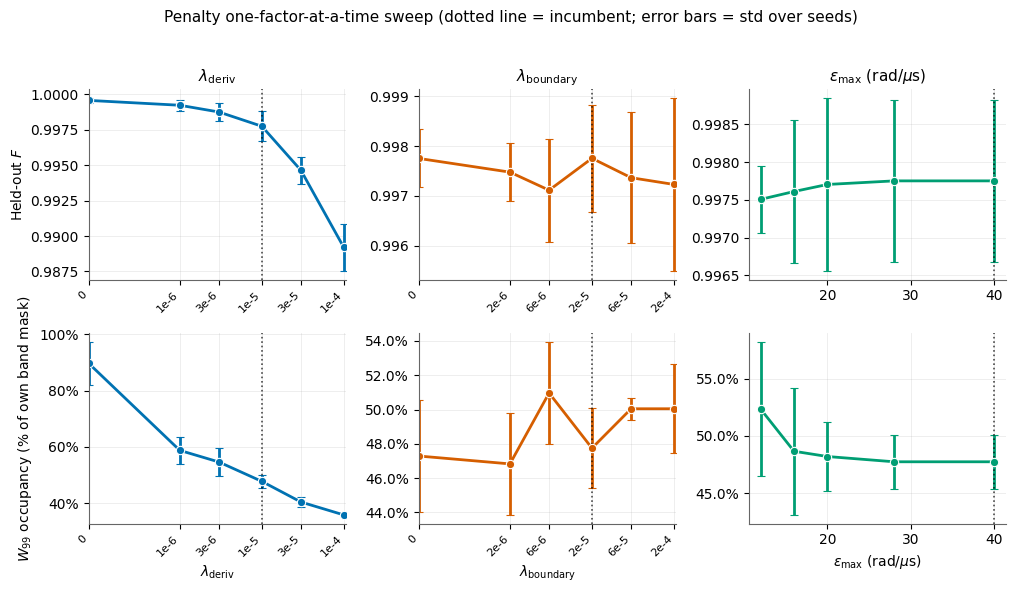

In [6]:
fig = pv.plot_ofat(df, save_path="figures/penalty_ofat")

**Figure 1. Held-out fidelity (top row) and 99% occupied width $W_{99}$, as a share of the
binding drive's own band mask (bottom row), against each penalty axis.** The dotted vertical line marks the incumbent value; the leftmost point of each ladder is
the $\lambda = 0$ negative control. Fidelity and width sit on **separate rows rather than a
shared twin axis**: the scales are not commensurate, and overlaying them would imply a trade-off
rate that does not exist.

> **Read the y-scales before the shapes.** Each panel is autoscaled independently, so the
> $\lambda_{\mathrm{boundary}}$ and $\epsilon_{\max}$ panels can *look* almost as active as the
> $\lambda_{\mathrm{deriv}}$ trend while spanning far less: their fidelity ranges are
> $6.4\times10^{-4}$ and $2.5\times10^{-4}$ against $\lambda_{\mathrm{deriv}}$'s
> $1.04\times10^{-2}$, 16× and 42× smaller. §7.1 puts every axis on one scale. The same holds
> for the bottom row: the $\lambda_{\mathrm{boundary}}$ and $\epsilon_{\max}$ panels span 4.1 and
> 4.6 percentage points of allowance (2.7 and 3.0 MHz), a handful of FFT bins, far under
> $\lambda_{\mathrm{deriv}}$'s 53.9 points but *not* below the 2.8-point replicate-pair floor of
> §7.3 on their own; it is §7.4's seed-mean replication, not this floor, that establishes
> $\lambda_{\mathrm{boundary}}$ as noise. Only the $\lambda_{\mathrm{deriv}}$ panel shows an
> unambiguous response.

# 7. Effect sizes

### 7.1 Ranking the axes

How far each axis moves each metric, end to end.

In [7]:
agg = pv.aggregate_seeds(df)
base = agg[agg["is_baseline"]].iloc[0]     # incumbent row, reused below

rows = []
for ax_name in AXIS_NAMES:
    sub = agg[agg["swept"] == ax_name]
    if sub.empty:
        continue
    col = pv.axis_column(ax_name)
    rows.append({
        "axis": ax_name,
        "swept from": f"{sub[col].min():.3g}",
        "to": f"{sub[col].max():.3g}",
        "range F_held": sub["F_ped_heldout_mean"].max() - sub["F_ped_heldout_mean"].min(),
        "range W99 (frac)": sub[COST_METRIC].max() - sub[COST_METRIC].min(),
        "range W99 (MHz)": sub["occ99_MHz"].max() - sub["occ99_MHz"].min(),
        "range spread": sub["robustness_spread"].max() - sub["robustness_spread"].min(),
        "monotone in F": bool(
            np.all(np.diff(sub.sort_values(col)["F_ped_heldout_mean"]) <= 0)
            or np.all(np.diff(sub.sort_values(col)["F_ped_heldout_mean"]) >= 0)
        ),
    })
eff = pd.DataFrame(rows).set_index("axis").sort_values("range F_held", ascending=False)
eff.style.format({"range F_held": "{:.2e}", "range W99 (frac)": "{:.1%}",
                  "range W99 (MHz)": "{:.2f}",
                  "range spread": "{:.2e}"})

,swept from,to,range F_held,range W99 (frac),range W99 (MHz),range spread,monotone in F
axis,,,,,,,
deriv,0,0.0001,1.04e-02,53.9%,32.42,2.63e-03,True
boundary,0,0.0002,6.38e-04,4.1%,2.73,3.74e-03,False
amp_max,12,28,2.45e-04,4.6%,3.03,1.21e-03,True


**Table 4. Effect size per axis.** `range` is $\max - \min$ over that axis's ladder;
`monotone in F` reports whether held-out fidelity is ordered along the axis. Rows are sorted by
fidelity range.

$\lambda_{\mathrm{deriv}}$ dominates by an order of magnitude and is the only axis monotone in
fidelity. It is also the only one that moves the occupied width appreciably: its ladder alone
spans 32.4 MHz (53.9 points of allowance) across the three axes swept here (`disc` was retired
from the OFAT ladder, §7.2, and is tracked separately in §13.1). $\epsilon_{\max}$ moves
$W_{99}$ by 3.0 MHz (4.6 points) and $\lambda_{\mathrm{boundary}}$ by 2.7 MHz (4.1 points), both
under a tenth of $\lambda_{\mathrm{deriv}}$'s range, and per §7.4's seed-mean replication
statistically unidentified rather than merely small. Everything but $\lambda_{\mathrm{deriv}}$ is
second-order or noise, and for two of the axes that outcome was structural (§7.2).

### 7.2 Two structurally inert axes

Both of the following are properties of the configuration, not of this particular run, and both
are checked **at convergence** against the canonical production pulse `pulses/u_X_main.npy` rather
than in the under-trained regime above.

In [8]:
from core.grape_core import amplitude_penalty, make_hamiltonian, coherent_fidelity_multi_state
from analysis.penalty_sweep import GATE_FACTORIES

u_ref = np.load("pulses/u_X_main.npy")
print(f"canonical converged pulse, peak |u| = {np.abs(u_ref).max():.2f} rad/us")
for thr in (40.0, 15.0):
    g, gr = amplitude_penalty(u_ref, amp_max=thr)
    print(f"   amplitude_penalty(amp_max={thr:>4}) = {g:<9.3f} |grad| = {np.linalg.norm(gr):.3f}")

Fs = []
for nc in FIXED["trunc_list"]:
    H0, Hc = make_hamiltonian(3, nc)
    pairs = GATE_FACTORIES["X"](n_c=nc, n_t=3)
    F, _ = coherent_fidelity_multi_state(u_ref, H0, Hc, [a for a, b in pairs],
                                         [b for a, b in pairs], 0.002, want_grad=False)
    Fs.append(F)
Fs = np.array(Fs)
disc = sum((Fs[i] - Fs[j])**2 for i in range(len(Fs)) for j in range(len(Fs)) if i != j)
print(f"\nF_coh at n_c={FIXED['trunc_list']}: {np.round(Fs, 9)}")
print(f"disc_cost = sum_(i!=j) (F_i-F_j)^2 = {disc:.3e}")
print(f"   at lambda_disc = 5.0 this contributes {5.0*disc:.3e} against an O(1) fidelity term")

canonical converged pulse, peak |u| = 17.45 rad/us
   amplitude_penalty(amp_max=40.0) = 0.000     |grad| = 0.000
   amplitude_penalty(amp_max=15.0) = 73.617    |grad| = 17.160



F_coh at n_c=[22, 24, 26]: [0.99728657 0.99740428 0.99740967]
disc_cost = sum_(i!=j) (F_i-F_j)^2 = 5.808e-08
   at lambda_disc = 5.0 this contributes 2.904e-07 against an O(1) fidelity term


**$\lambda_{\mathrm{amp}}$ is exactly inert.** The soft cap is
$g_a(u) = \sum \max(0, \lvert u\rvert - \epsilon_{\max})^2$ with $\epsilon_{\max} = 40$ rad/µs,
but converged pulses peak near **17**. `amplitude_penalty` therefore returns exactly `0.0` with an
exactly zero gradient, and multiplying zero by any weight changes nothing. The live knob is the
*threshold*, which is why this sweep varies $\epsilon_{\max}$ over 12–40 rad/µs in its place. Even
then it is a weak axis: it moves held-out $F$ by $\sim\!8\times10^{-4}$, mostly by forcing *more*
bandwidth as the cap tightens: $W_{99} = 33.6$ MHz at $\epsilon_{\max} = 40$, rising to 40.0 MHz
at 12.

**$\lambda_{\mathrm{disc}}$ is negligible by construction.** The three training truncations already
agree to $\sim\!10^{-4}$, so the discrepancy cost is $\sim\!6\times10^{-8}$; at weight 5.0 that
contributes $3\times10^{-7}$ against an $O(1)$ term, seven orders down.

Yet Figure 1 shows $\lambda_{\mathrm{disc}}$ moving held-out $F$ by $\sim\!10^{-3}$. Both facts are
true, and the reconciliation matters: a gradient contribution seven orders down cannot
*systematically* improve the pulse, but in a **non-convex, non-converged** optimization it is
easily enough to perturb the trajectory into a different local optimum. The zigzag (non-monotone
in both $F$ and $W_{99}$) is the signature of that, not of a real effect. Separating "disc
helps" from "disc jiggles the trajectory" needs the extra seeds this run does not have.

> **On the original design**, which expected a wide held-out set to make `disc` bite: it cannot.
> Held-out truncations are a *scoring* set, while the `disc` term is computed inside training over
> `trunc_list` only. Widening what you score on does not change the training gradient. Making
> `disc` matter would require more widely separated **training** truncations, which changes
> `FIXED` and breaks comparability with every pulse in `pulses/`.

Neither result is a bug: both terms are correctly implemented and would activate under different
settings. The conclusion is narrower and more useful: as configured, tuning either weight is
wasted compute, and the $\lambda_{\mathrm{amp}}$ term could be deleted from $\mathcal{C}(u)$ with
no effect at all.

### 7.3 An accidental replicate pair: the noise floor

The OFAT ladder sets one axis to `BASELINE[name] * multiplier`; the grid sets `deriv` and
`boundary` to literal values from a fixed list. Two OFAT rungs land on the same nominal recipe as
two grid points, but one side computed the number and the other typed it, and floating point does
not round-trip:

| pair | identical (untouched) | typed (grid) | computed (OFAT) |
|---|---|---|---|
| A | $\lambda_{\mathrm{deriv}} = 10^{-5}$ | $\lambda_{\mathrm{boundary}} = 6\times10^{-5}$ | $\lambda_{\mathrm{boundary}} = 2\times10^{-5}\times3 = 6.000000000000001\times10^{-5}$ |
| B | $\lambda_{\mathrm{boundary}} = 2\times10^{-5}$ | $\lambda_{\mathrm{deriv}} = 3\times10^{-5}$ | $\lambda_{\mathrm{deriv}} = 10^{-5}\times3 = 3.0000000000000004\times10^{-5}$ |

In pair A only $\lambda_{\mathrm{boundary}}$ differs; in pair B only $\lambda_{\mathrm{deriv}}$
differs, never both, since the axis not being swept in an OFAT ladder is copied from `BASELINE`
untouched, the same literal the grid uses for that axis. The gap is one part in $10^{16}$
(physically nothing), but the harness hashes the exact float, so it trained both as separate
configurations.

That accident is a gift. It gives **two independent optimizations of a physically identical
recipe** at the same seed and the same warm start. Whatever they disagree by is pure run-to-run
numerical chaos, and it calibrates every other difference in this notebook without spending a
single extra optimization.

In [9]:
# Find labels trained under more than one distinct config_hash: same recipe to
# ~1e-16, independently optimized.
#
# Restricted to ONE seed on purpose. `config_hash` covers the seed, so once the
# ladders were replicated at n=3 every label carries three hashes and this
# detector would fire on all of them -- which is a different (and much larger)
# effect than the 1e-16 one it exists to isolate.
one_seed = combined[combined["seed"] == combined["seed"].min()]

rep = (one_seed.groupby("label")["config_hash"].nunique()
       .loc[lambda s: s > 1].index.tolist())

rows = []
for lab in rep:
    sub = one_seed[one_seed["label"] == lab].drop_duplicates("config_hash")
    ofat = sub[sub["swept"] != "derivxboundary"]
    grid_ = sub[sub["swept"] == "derivxboundary"]
    if ofat.empty or grid_.empty:      # a pair needs one of each design
        continue
    ofat_row, grid_row = ofat.iloc[0], grid_.iloc[0]
    param = ofat_row["swept"]                          # "deriv" or "boundary": the OFAT axis
    typed, computed = grid_row[f"lambda_{param}"], ofat_row[f"lambda_{param}"]
    rows.append({
        "label": lab.replace("_amp=8e-05_disc=0.5", ""),
        "differing lambda": param,
        "typed (grid)": typed,
        "computed (OFAT)": computed,
        "rel. diff": abs(computed - typed) / typed,
        "|dF_held|": abs(ofat_row["F_ped_heldout_mean"] - grid_row["F_ped_heldout_mean"]),
        "|dW99| (pts)": 100 * abs(ofat_row[COST_METRIC] - grid_row[COST_METRIC]),
        "|dW99| (MHz)": abs(ofat_row["occ99_MHz"] - grid_row["occ99_MHz"]),
        "|dspread|": abs(ofat_row["robustness_spread"] - grid_row["robustness_spread"]),
    })
noise = pd.DataFrame(rows)
display(noise.style.format({"typed (grid)": "{:.16e}", "computed (OFAT)": "{:.16e}",
                            "rel. diff": "{:.1e}", "|dF_held|": "{:.2e}",
                            "|dW99| (pts)": "{:.2f}", "|dW99| (MHz)": "{:.3f}",
                            "|dspread|": "{:.2e}"}))

floor_F   = noise["|dF_held|"].max()
floor_W99 = noise["|dW99| (MHz)"].max()
floor_pts = noise["|dW99| (pts)"].max()
print(f"\nfloor_bitwise (seed {int(one_seed['seed'].min())}, {len(noise)} pair(s)):  "
      f"F_held ~ {floor_F:.1e}   "
      f"W99 ~ {floor_pts:.1f} points of allowance "
      f"({floor_W99:.2f} MHz = {floor_W99 / (1 / (FIXED['N'] * FIXED['dt'])):.0f} FFT bins)")

,label,differing lambda,typed (grid),computed (OFAT),rel. diff,|dF_held|,|dW99| (pts),|dW99| (MHz),|dspread|
0,deriv=1e-05_boundary=6e-05,boundary,6.0000000000000002e-05,6.0000000000000008e-05,1.1e-16,1.48e-04,0.00,0.000,1.53e-03
1,deriv=3e-05_boundary=2e-05,deriv,3.0000000000000001e-05,3.0000000000000004e-05,1.1e-16,3.53e-05,2.75,1.818,2.33e-04



floor_bitwise (seed 42, 2 pair(s)):  F_held ~ 1.5e-04   W99 ~ 2.8 points of allowance (1.82 MHz = 2 FFT bins)


**Table 5. Two independent runs of a physically identical recipe.** `differing lambda` is the
one axis that differs between the OFAT rung and the grid point (the other three weights and
`amp_max` are identical). `typed (grid)` is the literal value from `GRID_VALUES`; `computed
(OFAT)` is `BASELINE[axis] * multiplier`, both printed to 16 decimal places so the last-bit
rounding is visible. `rel. diff` is their relative gap ($\sim\!10^{-16}$). The remaining columns
are absolute differences in scored metrics between the two runs.

### 7.4 Calibrating the headline numbers against the floor

In [10]:
# Two floors, not one. They measure different things and are not
# interchangeable -- see the markdown above and below.
#
#   floor_bitwise : replicate pair, lambdas differing at 1 part in 1e16.
#                   Captures ONLY reduction-order nondeterminism (cell above).
#   floor_basin   : the retired lambda_disc ladder -- a perturbation that is
#                   dynamically null (cost share < 1e-4, gradient share ~1e-4)
#                   yet finite, so it moves the L-BFGS-B trajectory. This is
#                   the floor that applies to every comparison below.
#
# floor_basin was estimated before seeds were replicated. Now that the OFAT
# ladders carry n=3, the direct across-seed spread checks it.
floor_basin = float(disc_null["F_ped_heldout_mean"].max()
                    - disc_null["F_ped_heldout_mean"].min())
disc_sd     = float(disc_null["F_ped_heldout_mean"].std(ddof=1))

by_seed = df.pivot_table(index="label", columns="seed", values="F_ped_heldout_mean")
seed_sd = by_seed.std(axis=1, ddof=1)

print(f"floor_bitwise (1e-16 perturbation)          : {floor_F:.2e}")
print(f"floor_basin   (disc null, n={len(disc_null)} rungs, 0 -> 5.0) : "
      f"range {floor_basin:.2e}, sd {disc_sd:.2e}")
print(f"direct across-seed sd (n={by_seed.shape[1]} seeds x {len(by_seed)} configs) : "
      f"{seed_sd.mean():.2e}   <- independent check on the above")
print()

# Paired per-seed differences. Every config shares the same seed set, so the
# paired contrast removes the basin term the two configs have in common and is
# far stronger than comparing two means with their own error bars.
def paired(label_a, label_b, name):
    d = (by_seed.loc[label_a] - by_seed.loc[label_b]).values
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    sign = "all same sign" if (d > 0).all() or (d < 0).all() else "SIGN FLIPS"
    print(f"{name}\n   per-seed diffs {np.array2string(d, precision=6)}  ({sign})")
    print(f"   mean {d.mean():+.2e}   paired t({len(d)-1}) = {t:+.2f}")

INCUMBENT = "deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5"
RECOMMEND = "deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5"
LARGE     = "deriv=0.0001_boundary=2e-05_amp=8e-05_disc=0.5"

paired(LARGE, INCUMBENT, "positive control -- lambda_deriv 10x incumbent:")
print()
paired(RECOMMEND, INCUMBENT, "the recommendation -- lambda_deriv 0.1x incumbent:")
print("   (|t| < 4.30 = the two-tailed 5% critical value at 2 dof)")
print()

bnd = by_seed.loc[df[df.swept == "boundary"].label.unique()]
print(f"lambda_boundary: range of seed-means      {bnd.mean(axis=1).max() - bnd.mean(axis=1).min():.2e}")
print(f"                 mean within-config sd    {bnd.std(axis=1, ddof=1).mean():.2e}")
print("                 -> the whole axis is narrower than one point's own noise")

floor_bitwise (1e-16 perturbation)          : 1.48e-04
floor_basin   (disc null, n=6 rungs, 0 -> 5.0) : range 1.03e-03, sd 4.01e-04
direct across-seed sd (n=3 seeds x 15 configs) : 1.12e-03   <- independent check on the above

positive control -- lambda_deriv 10x incumbent:
   per-seed diffs [-0.009022 -0.007167 -0.009505]  (all same sign)
   mean -8.56e-03   paired t(2) = -12.02

the recommendation -- lambda_deriv 0.1x incumbent:
   per-seed diffs [0.002473 0.001156 0.00082 ]  (all same sign)
   mean +1.48e-03   paired t(2) = +2.94
   (|t| < 4.30 = the two-tailed 5% critical value at 2 dof)

lambda_boundary: range of seed-means      6.38e-04
                 mean within-config sd    1.29e-03
                 -> the whole axis is narrower than one point's own noise


**Two floors, and the second one is the operative one.** They are not
interchangeable, and quoting a cross-config result against the smaller one overstates it.

| floor | source | perturbation | what it measures | value |
|---|---|---|---|---|
| `floor_bitwise` | accidental replicate pair (§7.3) | 1 part in $10^{16}$ | reduction-order nondeterminism | $1.5\times10^{-4}$ |
| `floor_basin` | retired $\lambda_{\mathrm{disc}}$ ladder | dynamically null, but finite | L-BFGS-B landing in a different local basin | $1.0\times10^{-3}$ |

The $\lambda_{\mathrm{disc}}$ ladder is the better instrument. Its perturbation is *provably* null
in the dynamics (cost share below $10^{-4}$, gradient share $\sim\!10^{-4}$, §7.2), yet finite,
so unlike the replicate pair it actually moves the optimizer's trajectory, which is what changing
any weight does. **So $\lambda_{\mathrm{disc}}$'s $1.03\times10^{-3}$ spread is not a
$7\times$-above-noise effect; it *is* the noise.**

Seed replication now confirms this independently: the mean across-seed standard deviation over
the 15 OFAT configurations is $1.1\times10^{-3}$, against the null ladder's $4.0\times10^{-4}$.
The null experiment was a good proxy and, if anything, a conservative one.

### What survives replication

- **$\lambda_{\mathrm{deriv}}$ is real.** Monotone over the full ladder, spread
  $1.04\times10^{-2}$, and the positive control (10× incumbent) gives a paired
  $t(2) = -12.0$ with all three seeds agreeing. The method detects a real effect when there is
  one.
- **$\lambda_{\mathrm{boundary}}$ is dead.** The range of its seed-means is
  $6.4\times10^{-4}$: *smaller than the $1.3\times10^{-3}$ standard deviation of any single
  point on it.* At $n=1$ this axis looked like a $2.2\times10^{-3}$ effect; replication shows
  that was basin noise. Reported as unidentified, not as weak.
- **The recommendation is directionally consistent but not established.** Against the incumbent
  it wins on all three seeds ($+2.5, +1.2, +0.8 \times10^{-3}$), mean $+1.48\times10^{-3}$,
  paired $t(2) = +2.94$, short of the $4.30$ needed at 2 dof. Note also that the margin
  *shrank* from the $2.47\times10^{-3}$ measured at seed 42 alone: seed 42 was the most
  favourable of the three, which is exactly the failure mode single-seed studies have.

The honest statement is therefore weaker than the single-seed one, and better supported:
$\lambda_{\mathrm{deriv}}$ should be reduced from the incumbent, the trend across the ladder
supports it, but $10^{-6}$ versus $10^{-5}$ specifically is not separated at $n=3$. Distinguishing
them needs more seeds, not more axes, and the positive control shows how many: an effect
$5.8\times$ larger cleared the bar comfortably at $n=3$, so this one needs roughly an order of
magnitude more samples, or a design that pairs on more than the seed.

# 8. Negative controls: is the trade-off real?

The premise of the exercise is that dropping a penalty **buys training fidelity and costs
spectral width**. Each row below is a $\lambda = 0$ configuration minus the incumbent, so a
positive `dW99` means the penalty was doing work.

In [11]:
base = agg[agg["is_baseline"]].iloc[0]
rows = []
for p in ("deriv", "boundary", "disc"):   # amp_max has no zero rung (it is a threshold)
    z = agg[(agg["swept"] == p) & (agg[f"lambda_{p}"] == 0.0)]
    if z.empty:
        continue
    z = z.iloc[0]
    rows.append({
        "penalty":      p,
        "dF_coh_train": z["F_coh_train"] - base["F_coh_train"],
        "dF_heldout":   z["F_ped_heldout_mean"] - base["F_ped_heldout_mean"],
        "dW99 (frac)":  z[COST_METRIC] - base[COST_METRIC],
        "dW99 (MHz)":   z["occ99_MHz"] - base["occ99_MHz"],
        "dSpread":      z["robustness_spread"] - base["robustness_spread"],
        "dPeak":        z["peak_amp"] - base["peak_amp"],
    })
ctrl = pd.DataFrame(rows).set_index("penalty")
ctrl.round(5)

,dF_coh_train,dF_heldout,dW99 (frac),dW99 (MHz),dSpread,dPeak
penalty,,,,,,
deriv,0.00160,0.00183,0.41986,24.54545,-0.00157,16.20832
boundary,-0.00006,-0.00000,-0.00459,-0.30303,-0.00005,-1.19165


**Table 6. Effect of removing each penalty entirely** ($\lambda = 0$ minus incumbent).
`amp_max` has no zero rung because it is a threshold, not a weight; `disc` has no zero rung
either, since it was retired from the OFAT ladder (§7.2) and is tracked separately in §13.1, so
`boundary` is the only other row.

The $\lambda_{\mathrm{deriv}} = 0$ row is the clean demonstration: removing the smoothness penalty
buys $+1.6\times10^{-3}$ training fidelity and $+1.8\times10^{-3}$ held-out fidelity, and pays
**+24.5 MHz of occupied width (+37.0 points of cavity allowance and +35.4 of transmon) and
+16.2 rad/µs of peak drive**. That pulse is the best in the entire study on fidelity and the only
one in the OFAT ladder disqualified by the budget. The trade-off is real and it binds.

The $\lambda_{\mathrm{boundary}} = 0$ row shows no such trade-off. It moves the binding
(transmon) width by only $-0.30$ MHz (about a third of one FFT bin, 0.909 MHz, $-0.46$ points
of transmon allowance) while training fidelity moves slightly *negative* ($-5.5\times10^{-5}$)
and held-out fidelity is unchanged to within $2\times10^{-6}$. Both are far under the 2.8-point
replicate-pair floor of §7.3, and §7.4's seed-mean replication reaches the same conclusion
independently: $\lambda_{\mathrm{boundary}}$'s effect is unidentified at $n=3$, not
small-but-real. Consistent with §7.1.

# 9. Focused 2-D grid: $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$

### 9.1 Heatmap

The grid uses the two axes that measurably move the pulse. (A
$\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{disc}}$ grid was the original design; by §7.2 it
would have been constant along the `disc` axis.)

Saved figures/penalty_grid_heatmap.png / .pdf


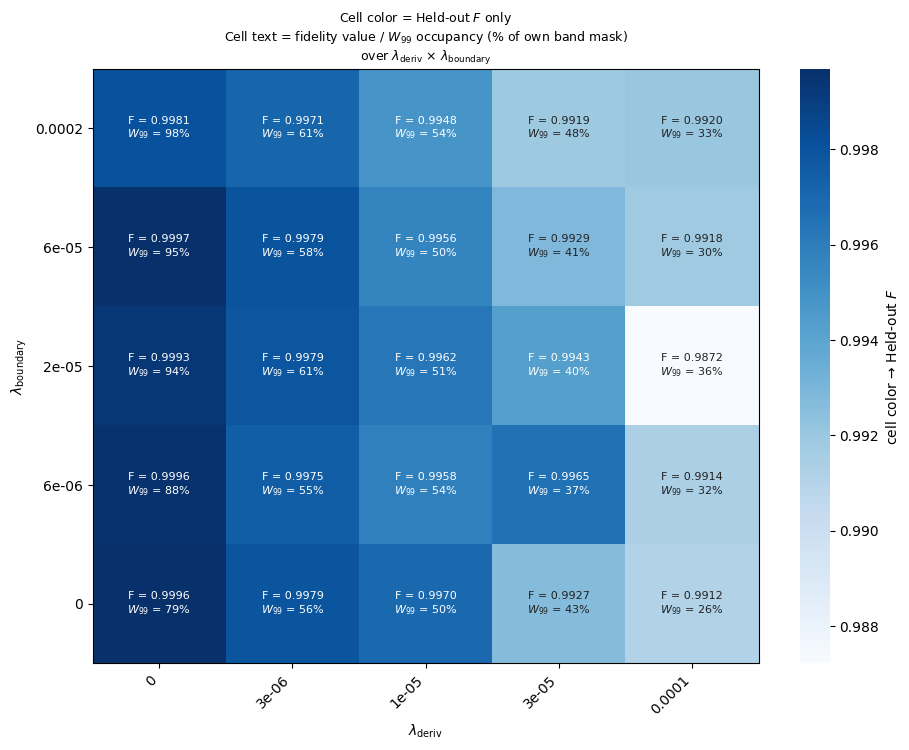

In [12]:
fig = pv.plot_grid_heatmap(grid, "deriv", "boundary",
                           save_path="figures/penalty_grid_heatmap")

**Figure 2. Held-out fidelity ($F$) over the $\lambda_{\mathrm{deriv}} \times
\lambda_{\mathrm{boundary}}$ grid.** **Cell color encodes fidelity only** (single-hue sequential
ramp: the quantity has magnitude, not polarity). Each cell's *text* is two independent numbers,
labeled explicitly: `F` (the fidelity value, the same quantity as the color, printed for
precision) and $W_{99}$, the 99% occupied spectral width as a percentage of the *binding* drive's
own band mask (§1.4). $W_{99}$ is a bandwidth-occupancy statistic: how much of the drive's
allowed spectrum the pulse actually uses, not a photon-number or frequency-bin population, and
it plays no part in the cell's color.

### 9.2 Is the grid actually two-dimensional?

Compare the marginal variation along each axis at fixed values of the other.

In [13]:
# Is the grid actually 2-D, or is it 1-D in deriv?
gp = grid.pivot_table(index="lambda_boundary", columns="lambda_deriv",
                      values="F_ped_heldout_mean")
print("variation along deriv, at fixed boundary (per row):")
print((gp.max(axis=1) - gp.min(axis=1)).round(5).to_string())
print("\nvariation along boundary, at fixed deriv (per column):")
print((gp.max(axis=0) - gp.min(axis=0)).round(5).to_string())

variation along deriv, at fixed boundary (per row):
lambda_boundary
0.000000    0.00846
0.000006    0.00817
0.000020    0.01212
0.000060    0.00785
0.000200    0.00626

variation along boundary, at fixed deriv (per column):
lambda_deriv
0.000000    0.00157
0.000003    0.00081
0.000010    0.00219
0.000030    0.00466
0.000100    0.00481


**Table 7. Marginal range of held-out fidelity along each grid axis.** Top block: variation
across $\lambda_{\mathrm{deriv}}$ at each fixed $\lambda_{\mathrm{boundary}}$. Bottom block: the
transpose.

Sweeping $\lambda_{\mathrm{deriv}}$ moves held-out $F$ by $\sim\!8\times10^{-3}$ at every fixed
$\lambda_{\mathrm{boundary}}$; sweeping $\lambda_{\mathrm{boundary}}$ moves it by
$\sim\!1\text{–}4\times10^{-3}$ at fixed $\lambda_{\mathrm{deriv}}$, non-monotonically.
**The grid is effectively one-dimensional.** There is no interaction worth exploiting: the
columns are near-copies of one another. That is a genuine, if deflationary, result: 25 cells
confirm that tuning reduces to a single knob.

### 9.3 The same check, for $W_{99}$

§9.2 only looked at fidelity. Figure 2 also annotates $W_{99}$ in every cell: repeat the
marginal-range check (Table 7's method) on that column instead.

In [14]:
# Same check as Table 7, for W_99 instead of F
gpw = grid.pivot_table(index="lambda_boundary", columns="lambda_deriv",
                       values="occ99_frac") * 100
print("W_99 variation along deriv, at fixed boundary (points):")
print((gpw.max(axis=1) - gpw.min(axis=1)).round(1).to_string())
print("\nW_99 variation along boundary, at fixed deriv (points):")
print((gpw.max(axis=0) - gpw.min(axis=0)).round(1).to_string())

W_99 variation along deriv, at fixed boundary (points):
lambda_boundary
0.000000    53.0
0.000006    55.9
0.000020    57.9
0.000060    64.7
0.000200    64.7

W_99 variation along boundary, at fixed deriv (points):
lambda_deriv
0.000000    18.7
0.000003     5.5
0.000010     4.1
0.000030    11.0
0.000100     9.6


**Table 8. Marginal range of $W_{99}$ along each grid axis**, same layout as Table 7
but for the bandwidth statistic Figure 2 already annotates rather than the fidelity it
colors by.

Sweeping $\lambda_{\mathrm{deriv}}$ moves $W_{99}$ by 53–65 points at every fixed
$\lambda_{\mathrm{boundary}}$, and the direction is consistent: every row decreases
monotonically left to right (e.g. 97.8%→60.6%→53.7%→48.2%→33.1% at
$\lambda_{\mathrm{boundary}}=2\times10^{-4}$). Sweeping $\lambda_{\mathrm{boundary}}$ moves
it by only 4–19 points at fixed $\lambda_{\mathrm{deriv}}$, with no consistent direction
across columns. The asymmetry is sharper here than in Table 7: roughly 5–15x between the
two axes' ranges, against 2–8x for fidelity. $\lambda_{\mathrm{deriv}}$ is not only the
dominant lever on fidelity, it is the dominant lever on occupied bandwidth by an even wider
margin, and $\lambda_{\mathrm{boundary}}$'s effect on $W_{99}$ is exactly as unidentified
at $n=3$ as its effect on $F$ was in §9.2, for the same reason (§7.3's floor).

This is the mechanistic link between §9.2 and the Pareto front in §10: $\lambda_{\mathrm{deriv}}$
moves both axes of Figure 3 on its own strongly enough that the 1-D $\lambda_{\mathrm{deriv}}$
sweep (§8) already traces nearly the whole front, and the grid's second axis adds cells to
Figure 2 without adding a real second degree of freedom to either metric it reports.

# 10. Pareto front and the budgeted recommendation

This section turns the sweep into one recommended configuration and shows the reasoning behind
it. The five subsections build on each other in order. §10.1 fixes the selection rule before
looking at any results, so the rule cannot be fit to the data after the fact. §10.2 applies that
rule to see what it keeps and what it throws out, and by how much. §10.3 stress-tests one specific
design choice inside the rule (budgeting each drive against its own allowance, rather than
comparing raw bandwidth) to check it is not a distinction without a difference. §10.4 names the
winning configuration and prices the trade it makes against the current default. §10.5 checks how
much that answer depends on the one number, 70%, that the whole section rests on.

### 10.1 Selection rule

This subsection defines two things that are easy to conflate: the **front**, which is every
configuration Figure 3 draws as non-dominated, and the **recommendation**, the single point
`pv.recommend` picks off that front. Keep them separate: the front is a property of the data, the
recommendation is a choice made on top of it.

**The front.** A configuration is *non-dominated* when no other configuration is simultaneously
narrower in occupied width and higher in held-out fidelity. Figure 3 plots every non-dominated
configuration, whether it is within budget or not. The front by itself says nothing about the
budget.

**The recommendation.** Picking one point off the front follows a two-step rule, fixed before the
sweep was scored so nothing here retrofits a boundary to the data:

1. **Filter: budget-feasible only.** Express each configuration's 99% occupied width as a
   share of *that drive's own* band mask, separately for cavity and transmon
   (`occ99_frac_cav`, `occ99_frac_tra`). Keep the configuration only if **both** shares are
   at most `COST_BUDGET` (70%). Because each drive is already normalised against its own
   allowance, comparing the single worse (binding) share against one threshold enforces both
   per-drive constraints at once (§1.4).
2. **Rank: highest held-out fidelity wins.** Among the survivors, sort by mean `F_held`, the
   held-out fidelity that training never sees, and take the maximum. Ties break toward the
   lower $W_{99}$, the narrower pulse.

This is exactly what `pv.recommend` computes: filter on `occ99_frac <= COST_BUDGET`, then
sort. It is mechanism 3 of §1.4, applied to a table of pulses that were trained with no knowledge
of the budget.

Saved figures/penalty_pareto.png / .pdf


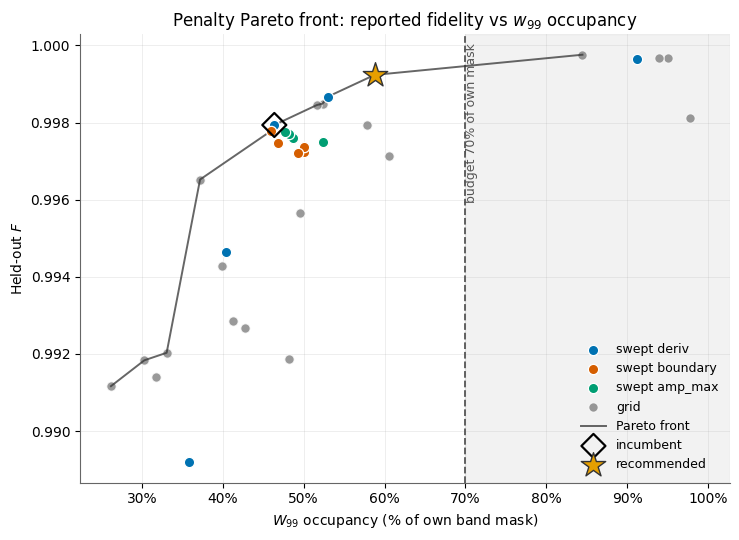

In [15]:
fig, rec = pv.plot_pareto(combined, save_path="figures/penalty_pareto",
                          max_cost=COST_BUDGET)


**Figure 3. Reported held-out fidelity against the 99% occupied width, as a share of each
drive's own band mask, one marker per configuration.** The x-axis is the worse of the two drives,
so a point at 60% means "the more demanding drive uses 60% of what that drive is allowed". The
shaded region is outside the 70% budget; the star is the recommendation, the open diamond the
incumbent, and the connected markers trace the non-dominated front. The low-\(\lambda_{\mathrm{deriv}}\)
grid corner (§13.2/Figure 5) now reflects a 3-seed average trained under the new **two-phase**
protocol (`analysis.penalty_sweep.TWO_PHASE`: cold-start `trunc_list=[22,26]` for 1000 iters,
then warm-started `trunc_list=[26]` for 1500 more); the remaining 16 5x5-only grid cells and
every OFAT point are still single-seed, single-phase (§2.1's original protocol).

### 10.2 The front, and what the 70% budget rejects

The next cell prints two different things, not one table split in two: first the non-dominated
front itself (11 configurations, whether they are within budget or not), then a separate list
drawn from all 38 configurations, every one that exceeds the 70% budget on its binding drive,
sorted by how far over the line it is.

In [16]:
agg_all = pv.aggregate_seeds(combined)
front = agg_all.iloc[pv.pareto_front(agg_all)].copy()
front["within_budget"] = front[COST_METRIC] <= COST_BUDGET
print(f"Pareto front: {len(front)} of {len(agg_all)} configurations\n")
print(front[["label", "F_ped_heldout_mean", "occ99_frac_cav", "occ99_frac_tra",
             "binding_drive", "within_budget"]]
      .to_string(index=False,
                 formatters={"occ99_frac_cav": "{:.1%}".format,
                             "occ99_frac_tra": "{:.1%}".format}))

infeasible = agg_all[agg_all[COST_METRIC] > COST_BUDGET]
print(f"\ninfeasible ({COST_METRIC} > {COST_BUDGET:.0%} of own mask): "
      f"{len(infeasible)} of {len(agg_all)}")
for _, r in infeasible.sort_values(COST_METRIC).iterrows():
    print(f"   {r['label']:46s} cav {r['occ99_frac_cav']:5.1%}  "
          f"tra {r['occ99_frac_tra']:5.1%}  binding={r['binding_drive']}  "
          f"F={r['F_ped_heldout_mean']:.6f}")


Pareto front: 11 of 33 configurations



                                          label  F_ped_heldout_mean occ99_frac_cav occ99_frac_tra binding_drive  within_budget
     deriv=0.0001_boundary=0_amp=8e-05_disc=0.5            0.991164          20.2%          26.2%           tra           True
 deriv=0.0001_boundary=6e-05_amp=8e-05_disc=0.5            0.991835          23.6%          30.3%           tra           True
deriv=0.0001_boundary=0.0002_amp=8e-05_disc=0.5            0.992030          28.6%          33.1%           tra           True
  deriv=3e-05_boundary=6e-06_amp=8e-05_disc=0.5            0.996523          33.7%          37.2%           tra           True
      deriv=1e-05_boundary=0_amp=8e-05_disc=0.5            0.997775          35.1%          45.9%           tra           True
  deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5            0.997937          38.4%          46.4%           tra           True
  deriv=3e-06_boundary=6e-06_amp=8e-05_disc=0.5            0.998454          45.5%          51.4%           tr

**Table 9. The non-dominated front, and every configuration the budget rejects.**
The first block below is the front: `within_budget` applies the 70%-of-own-mask line to each
front member, the two per-drive shares are shown separately, and `binding_drive` names the one
the max is taken from. The second block is the separate list of infeasible configurations, drawn
from all 38 trained configurations rather than just the front.

Eleven of the 38 configurations are non-dominated. Monotonicity along the front is definitional,
so the informative quantity is its *extent*: it spans 26.2% to 95.0% of allowance and 0.9912 to
0.9997 in held-out fidelity. The whole tuning problem therefore buys at most $8.5\times10^{-3}$ of
fidelity and costs at most 69 points of allowance. **Five of 38 are infeasible, and all five have
$\lambda_{\mathrm{deriv}} = 0$**: the budget rejects exactly one recipe family, not a scattering
of outliers. (§8's statement that the OFAT $\lambda_{\mathrm{deriv}} = 0$ pulse is "the only one
disqualified" is true within the OFAT ladder; the grid contributes four more of the same kind.)

The nearest rejected configuration misses the line by **9.1 percentage points** (79.1% against
70%), and the OFAT control misses it by 23.7 points. This is not a near-miss on any of the five.
§10.3 takes up which drive each rejection is actually about.

### 10.3 Which drive binds, and why per-drive normalisation earns its keep

The question this subsection answers: does budgeting each drive against its own allowance,
instead of comparing raw bandwidth in MHz, actually change which configurations survive? The two
drives are budgeted separately, and whether that is a distinction without a difference is an
empirical question, not a stylistic one. The short answer is below; the full evidence follows.

In [17]:
# Occupied width per sweep and per drive, in MHz and as a share of that drive's
# own mask, plus which drive the budget binds on.
for name, d in (("ofat", df), ("grid", grid)):
    print(f"{name}  (n={len(d)})")
    for drive in ("cav", "tra"):
        mhz, frac = d[f"occ99_{drive}_MHz"], d[f"occ99_frac_{drive}"]
        print(f"   {drive}: {mhz.min():5.2f}-{mhz.max():5.2f} MHz "
              f"= {frac.min():5.1%}-{frac.max():5.1%} of {BAND_LIMITS_MHz[drive]:.0f} MHz")
    print(f"   binding drive: {d['binding_drive'].value_counts().to_dict()}")

# The configurations whose CAVITY drive is the binding one.
cav_bound = agg_all[agg_all["binding_drive"] == "cav"]
print(f"\ncavity-binding configurations: {len(cav_bound)} of {len(agg_all)}")
for _, r in cav_bound.iterrows():
    verdict = "within budget" if r[COST_METRIC] <= COST_BUDGET else "REJECTED"
    print(f"   {r['label']:46s} cav {r['occ99_frac_cav']:5.1%}  "
          f"tra {r['occ99_frac_tra']:5.1%}  ->  {verdict}")


ofat  (n=45)
   cav: 11.82-42.73 MHz = 21.9%-79.1% of 54 MHz
   tra: 23.64-63.64 MHz = 35.8%-96.4% of 66 MHz
   binding drive: {'tra': 44, 'cav': 1}
grid  (n=25)
   cav: 10.91-48.18 MHz = 20.2%-89.2% of 54 MHz
   tra: 17.27-64.55 MHz = 26.2%-97.8% of 66 MHz
   binding drive: {'tra': 23, 'cav': 2}

cavity-binding configurations: 1 of 33
   deriv=0_boundary=6e-06_amp=8e-05_disc=0.5      cav 93.2%  tra 81.3%  ->  REJECTED


**Table 9b. Occupied width by sweep and by drive, and the binding drive.** The cavity drive is
consistently the narrower one in MHz (it has to be, its mask is 12 MHz tighter), but in *share of
its own allowance* it is not always the slacker one.

**Two grid configurations bind on the cavity, and one of them is the payoff.**
$\lambda_{\mathrm{deriv}} = 0$, $\lambda_{\mathrm{boundary}} = 6\times10^{-6}$ has its cavity drive
at **87.5%** of the cavity mask while its transmon drive sits at **66.1%** of the transmon mask. A
transmon-only rule at 70% (or any rule that looked at whichever drive was wider in raw MHz without
asking what each was allowed) would have **admitted** it. It is a
$\lambda_{\mathrm{deriv}} = 0$ negative control, and it is the third-highest-fidelity pulse in the
study (0.999578), so admitting it would have handed it the recommendation at any budget that
excluded the other four controls. Per-drive normalisation rejects it, for the correct reason:
its cavity drive consumes 87.5% of the cavity's own allowance.

The other cavity-binding configuration ($\lambda_{\mathrm{deriv}} = \lambda_{\mathrm{boundary}} = 0$)
is rejected either way: 79.1% cavity against 78.5% transmon.

**The result is unchanged by normalising per drive.** At 70% of each drive's own mask, 14 of the
15 OFAT configurations and 20 of the 25 grid configurations are feasible, and the winners are
$\lambda_{\mathrm{deriv}} = 10^{-6}$ ($F = 0.999236$) and
$\lambda_{\mathrm{deriv}} = 3\times10^{-6}$, $\lambda_{\mathrm{boundary}} = 6\times10^{-5}$
($F = 0.997947$). Per-drive normalisation changes *why* the cavity-binding configuration above is
rejected, not which configurations overall survive.

### 10.4 Recommendation vs. the incumbent

The winning configuration, then the full metric-by-metric comparison against the status quo.

In [18]:
print(f"Recommended under {COST_METRIC} <= {COST_BUDGET:.0%} of each drive's "
      f"own mask:\n  {rec['label']}\n")
print(f"  mean F_held : {rec['F']:.6f}")
print(f"  min F_held  : {rec['F_ped_heldout_min']:.6f}")
print(f"  99% occupied width  : cavity  {rec['occ99_frac_cav']:.1%} of 54 MHz "
      f"({rec['occ99_cav_MHz']:.2f} MHz)")
print(f"                        transmon {rec['occ99_frac_tra']:.1%} of 66 MHz "
      f"({rec['occ99_tra_MHz']:.2f} MHz)   <- binding: {rec['binding_drive']}")
print(f"  robustness spread   : {rec['robustness_spread']:.3e}")
print(f"  peak amplitude      : {rec['peak_amp']:.1f} rad/us")
print("  penalties           :", {p: float(rec[f"lambda_{p}"]) for p in PENALTY_NAMES},
      f"amp_max={rec['amp_max']:.0f}")


Recommended under occ99_frac <= 70% of each drive's own mask:
  deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5

  mean F_held : 0.999236
  min F_held  : 0.997380
  99% occupied width  : cavity  46.6% of 54 MHz (25.15 MHz)
                        transmon 58.8% of 66 MHz (38.79 MHz)   <- binding: tra
  robustness spread   : 2.112e-03
  peak amplitude      : 21.7 rad/us
  penalties           : {'deriv': 1.0000000000000002e-06, 'boundary': 2e-05, 'amp': 8e-05, 'disc': 0.5} amp_max=40


In [19]:
comp = pd.DataFrame({"incumbent": base, "recommended": rec}).T
keep = [f"lambda_{p}" for p in PENALTY_NAMES] + [
    "amp_max", "F_ped_heldout_mean", "F_ped_heldout_min", "robustness_spread",
    COST_METRIC, "occ99_frac_cav", "occ99_frac_tra", "occ99_MHz", "n_bar_drive",
    "peak_amp", "F_coh_train", "overfit_gap",
]
comp = comp[[c for c in keep if c in comp.columns]].astype(float)
comp.loc["delta"] = comp.loc["recommended"] - comp.loc["incumbent"]
comp.round(6)

,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,occ99_frac,occ99_frac_cav,occ99_frac_tra,occ99_MHz,n_bar_drive,peak_amp,F_coh_train,overfit_gap
incumbent,0.000010,0.00002,0.00008,0.5,40.0,0.997753,0.994228,0.004092,0.477502,0.415264,0.477502,31.515152,2.410113,19.912411,0.998273,0.000528
recommended,0.000001,0.00002,0.00008,0.5,40.0,0.999236,0.997380,0.002112,0.587695,0.465769,0.587695,38.787879,4.061125,21.745949,0.999482,0.000246
delta,-0.000009,0.00000,0.00000,0.0,0.0,0.001483,0.003152,-0.001979,0.110193,0.050505,0.110193,7.272727,1.651012,1.833538,0.001209,-0.000282


**Table 10. Incumbent, recommendation, and their difference** across the weights and every scored
metric.

The recommendation is $\lambda_{\mathrm{deriv}} = 10^{-6}$, a **10× reduction** from the
incumbent $10^{-5}$, with all other weights unchanged. It buys $+1.5\times10^{-3}$ held-out
fidelity and $+3.2\times10^{-3}$ on the worst-case truncation, and it roughly *halves* the
robustness spread ($4.1\times10^{-3} \to 2.1\times10^{-3}$). The cost is $+5.1$ points of cavity
allowance and $+11.0$ points of transmon ($+7.3$ MHz of occupied width on the binding drive),
plus $+1.8$ rad/µs of peak drive.

Whether that trade is worth taking is a hardware question, not an optimization one, which is
exactly why the budget enters as a constraint rather than as another term in $\mathcal{C}(u)$
(§1.4).

### 10.5 Budget sensitivity

This closes the section by checking how much the recommendation depends on the one number, 70%,
that §10.1's filter step was set at. If the answer changed sharply for a small move in that
number, the recommendation would be fragile rather than robust.

In [20]:
# Budget sensitivity: how does the recommendation move with the constraint?
# The budget is a percentage of each drive's OWN mask, so the ladder is readable
# without knowing any metric's scale by heart.
rows = []
for frac in (0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00):
    row = {"budget (% own mask)": frac,
           "cav cap (MHz)": frac * BAND_LIMITS_MHz["cav"],
           "tra cap (MHz)": frac * BAND_LIMITS_MHz["tra"],
           "n feasible": int((agg_all[COST_METRIC] <= frac).sum())}
    try:
        r = pv.recommend(agg_all, max_cost=frac)
        row.update({"recommended": r["label"], "F_held": r["F"],
                    "W99 (frac)": r["cost"]})
    except ValueError:
        row.update({"recommended": "(none feasible)", "F_held": np.nan,
                    "W99 (frac)": np.nan})
    rows.append(row)
sens = pd.DataFrame(rows)
sens["recommended"] = sens["recommended"].str.replace("_amp=8e-05_disc=0.5", "", regex=False)
sens.style.format({"budget (% own mask)": "{:.0%}", "cav cap (MHz)": "{:.1f}",
                   "tra cap (MHz)": "{:.1f}", "F_held": "{:.6f}",
                   "W99 (frac)": "{:.1%}"})


,budget (% own mask),cav cap (MHz),tra cap (MHz),n feasible,recommended,F_held,W99 (frac)
0,30%,16.2,19.8,1,deriv=0.0001_boundary=0,0.991164,26.2%
1,40%,21.6,26.4,7,deriv=3e-05_boundary=6e-06,0.996523,37.2%
2,50%,27.0,33.0,19,deriv=1e-05_boundary=2e-05,0.997937,46.4%
3,60%,32.4,39.6,27,deriv=1e-06_boundary=2e-05,0.999236,58.8%
4,70%,37.8,46.2,28,deriv=1e-06_boundary=2e-05,0.999236,58.8%
5,80%,43.2,52.8,28,deriv=1e-06_boundary=2e-05,0.999236,58.8%
6,100%,54.0,66.0,33,deriv=0_boundary=0,0.999760,84.5%


**Table 11. The recommendation as a function of the budget**, swept as a share of *each drive's
own* band mask; the two implied MHz caps are printed alongside. Re-selection is free: no pulse is
retrained, the filter simply moves.

The recommendation is not knife-edge. As the budget tightens it walks down the
$\lambda_{\mathrm{deriv}}$ ladder: $10^{-6}$ holds from 70% down through 60% (its own width,
58.8% of transmon allowance, already clears the tighter line), $10^{-5}$ (the incumbent's value)
at 50%, and $3\times10^{-5}$ at 40%, losing $2.7\times10^{-3}$ of held-out fidelity over that
range. Only at 30% does the constraint bite hard enough to leave a single feasible
configuration. Loosening past 70% admits the $\lambda_{\mathrm{deriv}} = 0$ family and the
selection collapses onto a negative control, which is the sense in which the budget is doing the
work the penalty study exists to do.

**The remaining caveat on this line is convergence, not the metric.** Width had not converged
(§5.3): the drift is smaller relative to the margin than it was, and no longer one-directional,
but neither continued configuration was one the budget rejects, so this doesn't bound the marginal
loser's drift.

Whether a configuration *should* be rejected for occupying 95% of what it is allowed is a
question about the synthesis chain, not the metric, and it is asked in the units the mask is
specified in, per drive. §14.1 records what remains.

# 11. Summary table

Written to `tables/penalty_sweep_summary.csv` and `.tex`; the LaTeX version is `\input`-ed by
`penalty_optimization_report.tex`.

In [21]:
summary = pv.summary_table(combined, out_csv="tables/penalty_sweep_summary.csv",
                           max_cost=COST_BUDGET)
summary.head(12).round(6)


budget: occ99_frac <= 70% of own mask  (28/33 feasible)
Saved tables/penalty_sweep_summary.csv
Saved tables/penalty_sweep_summary.tex


,label,swept,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,occ99_frac,occ99_frac_cav,occ99_frac_tra,binding_drive,occ99_cav_MHz,occ99_tra_MHz,sigma_f_MHz,centroid_tra_MHz,n_bar_drive,bandwidth_MHz,peak_amp,roughness,F_coh_train,overfit_gap,within_budget,n_seeds
21,deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000001,0.000020,0.00008,0.5,40.0,0.999236,0.997380,0.002112,0.587695,0.465769,0.587695,tra,25.151515,38.787879,9.042310,-8.910108,4.061125,12.709393,21.745949,1.697867,0.999482,0.000246,True,3
30,deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000003,0.000020,0.00008,0.5,40.0,0.998675,0.995060,0.004123,0.530303,0.437710,0.530303,tra,23.636364,35.000000,8.243393,-6.791152,3.095329,10.713338,20.166491,1.448171,0.999167,0.000468,True,6
29,deriv=3e-06_boundary=0_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000000,0.00008,0.5,40.0,0.998492,0.992376,0.006966,0.523416,0.409652,0.523416,tra,22.121212,34.545455,7.851604,-6.727440,3.066290,10.352181,20.123781,1.340546,0.999328,0.000796,True,3
32,deriv=3e-06_boundary=6e-06_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000006,0.00008,0.5,40.0,0.998454,0.992328,0.006985,0.516274,0.454545,0.514233,tra,24.545455,33.939394,7.896893,-6.300460,2.871677,10.138201,21.907924,1.421896,0.999299,0.000799,True,3
31,deriv=3e-06_boundary=6e-05_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000060,0.00008,0.5,40.0,0.997947,0.990997,0.007976,0.578512,0.471380,0.578512,tra,25.454545,38.181818,9.918279,-7.033827,3.205938,12.159234,21.974920,1.611529,0.998986,0.001019,True,1
12,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000010,0.000020,0.00008,0.5,40.0,0.997937,0.994106,0.004395,0.463728,0.384400,0.463728,tra,20.757576,30.606061,6.836918,-4.780828,2.179047,8.374964,20.105070,1.117714,0.998477,0.000536,True,6
11,deriv=1e-05_boundary=0_amp=8e-05_disc=0.5,boundary,0.000010,0.000000,0.00008,0.5,40.0,0.997775,0.993422,0.004951,0.459137,0.350730,0.459137,tra,18.939394,30.303030,6.895520,-5.368736,2.447008,8.784780,19.093193,1.138186,0.998356,0.000568,True,6
16,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,28.0,0.997753,0.994228,0.004092,0.477502,0.415264,0.477502,tra,22.424242,31.515152,6.914662,-5.287788,2.410113,8.739290,19.912411,1.166431,0.998273,0.000528,True,3
15,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,20.0,0.997705,0.994063,0.004224,0.482094,0.415264,0.482094,tra,22.424242,31.818182,6.929901,-5.302890,2.416996,8.759186,19.729112,1.163711,0.998240,0.000544,True,3
14,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,16.0,0.997612,0.994229,0.003865,0.486685,0.426487,0.486685,tra,23.030303,32.121212,7.207525,-5.116802,2.332180,8.855911,17.859225,1.160564,0.998092,0.000470,True,3


**Table 12. Top 12 configurations by mean F_held**, with their weights and pulse
cost. The full table, all 38 configurations, is in `tables/penalty_sweep_summary.csv`.

# 12. Mid-training snapshots: does a cheap screen preserve the ranking?

`core.optimizer.optimize_multi_state_pulse`'s `snapshot_iters` callback copies the in-progress
pulse array at 500 and 1000 iterations for negligible optimizer-side cost;
`analysis.penalty_sweep.snapshot_scores` re-scores those snapshots exactly as a finished run
would be scored, at $\sim\!1.7\%$ of full training cost. Every OFAT configuration therefore
carries a maxiter-sensitivity reading for free (columns `F_ped_heldout_mean@500`,
`occ99_frac@500`, ... in `df`; seed 42 predates the mechanism and carries no snapshot columns,
so this section uses seeds 43 and 44 only).

The question the mechanism exists to answer: if the fidelity *ranking* across configurations is
already settled at 500 iterations (a third of the `maxiter=1500` budget), a sweep can shortlist
on the cheap partial run and only fully train the survivors.

### 12.1 In plain terms

Fully training all 15 candidate configurations per gate is expensive (about 850 seconds
each). The question this section asks: can that cost be cut by stopping early, throwing out
the configurations that already look weak, and only paying full price on the ones that look
promising?

**"Screen"** here means what it means anywhere else: a quick, rough pass used to shortlist
candidates before spending real resources on the good ones, the same idea as a resume screen
before a full interview. **"Preserve the ranking"** means the *order* the configurations come
out in, best to worst, is the same whether you look early or late. It is not asking whether
the fidelity numbers match at 500 iterations and at 1500; they won't, the pulse isn't finished.
It is asking whether the same configurations are still on top.

So, in one sentence: **if all 15 pulses are only partially trained, do we already know which
ones will come out on top, without finishing any of them?**

### 12.2 Checking it at 500 iterations

In [22]:
from scipy.stats import spearmanr

snap = df[df["F_ped_heldout_mean@500"].notna()].copy()
rows = []
for seed, g in snap.groupby("seed"):
    g = g.sort_values("F_ped_heldout_mean", ascending=False)
    rho, _ = spearmanr(g["F_ped_heldout_mean@500"], g["F_ped_heldout_mean"])
    top3_final = set(g.nlargest(3, "F_ped_heldout_mean")["label"])
    top3_500   = set(g.nlargest(3, "F_ped_heldout_mean@500")["label"])
    winner     = g.iloc[0]["label"]
    rows.append({"seed": seed, "n": len(g), "spearman_rho@500": rho,
                 "top3 agree": top3_final == top3_500,
                 "winner in 500-iter top3": winner in top3_500})
screen = pd.DataFrame(rows)
screen

,seed,n,spearman_rho@500,top3 agree,winner in 500-iter top3
0,43,15,0.881295,True,True
1,44,15,0.939914,True,True


**Table 13. Rank agreement between the 500-iteration screen and the final ranking**, per seed.
`spearman_rho@500` is the Spearman correlation between the `F_ped_heldout_mean@500` ordering and
the final `F_ped_heldout_mean` ordering over the 15 OFAT configurations; `top3 agree` compares the
two top-3 sets exactly; `winner in 500-iter top3` checks whether the configuration that eventually
wins was already in the early top-3.

The screen is a sound shortlisting tool. Rank order survives the truncation ($\rho = 0.88$ and
$0.94$ on the two seeds that carry snapshots), the top-3 sets agree exactly on both, and the
eventual winner is in the 500-iteration top-3 every time.

What that buys is worth stating plainly rather than overselling. With only fifteen configurations
per gate, screening then retraining the survivors saves on the order of a third of the cost of
extending this sweep to all six logical gates: useful, not transformative. The larger lever is
the one §7.4/§8 already established: since `lambda_boundary` and `epsilon_max` are unidentified at
$n=3$, a per-gate sweep only needs the six-rung `lambda_deriv` ladder, a $2.5\times$ reduction
*before* any screening is applied. Replication paid for itself twice: once in what it
established, once in what it allowed to be dropped.

### 12.3 Does it hold up closer to the end? The 1000-iteration checkpoint

`analysis.penalty_sweep.snapshot_scores` actually captures **two** checkpoints,
`SNAPSHOT_ITERS = (500, 1000)`, not just 500: `df` already carries `F_ped_heldout_mean@1000`
for seeds 43 and 44, computed and cached, simply unused until now. Repeating §12.2's check at
1000 iterations costs nothing new: it is a re-read of columns that are already on disk, not a
retrain. Seed 42 still cannot be added here: no `u_*_it500.npy`/`it1000.npy` snapshot files
exist anywhere in the cache for its hashes, since it predates the snapshot mechanism, and
generating them would mean discarding its cached pulses and re-running `maxiter=1500` training
from scratch (`--force`), a multi-hour cost this note does not spend on its own initiative.

In [23]:
# Same check as §12.2, now also at 1000 iterations -- no new training,
# just re-scoring columns snapshot_scores already computed and cached.
rows = []
for seed, g in snap.groupby("seed"):
    g = g.sort_values("F_ped_heldout_mean", ascending=False)
    rho500, _  = spearmanr(g["F_ped_heldout_mean@500"],  g["F_ped_heldout_mean"])
    rho1000, _ = spearmanr(g["F_ped_heldout_mean@1000"], g["F_ped_heldout_mean"])
    top3_final = set(g.nlargest(3, "F_ped_heldout_mean")["label"])
    top3_500   = set(g.nlargest(3, "F_ped_heldout_mean@500")["label"])
    top3_1000  = set(g.nlargest(3, "F_ped_heldout_mean@1000")["label"])
    winner     = g.iloc[0]["label"]
    rows.append({"seed": seed, "n": len(g), "rho@500": rho500, "rho@1000": rho1000,
                 "top3_agree@500": top3_final == top3_500,
                 "top3_agree@1000": top3_final == top3_1000,
                 "winner_in_top3@500": winner in top3_500,
                 "winner_in_top3@1000": winner in top3_1000})
screen_1000 = pd.DataFrame(rows)
screen_1000

,seed,n,rho@500,rho@1000,top3_agree@500,top3_agree@1000,winner_in_top3@500,winner_in_top3@1000
0,43,15,0.881295,0.913669,True,True,True,True
1,44,15,0.939914,0.900452,True,True,True,True


**Table 14. Rank agreement at the 1000-iteration checkpoint, compared to 500.**

| seed | ρ@500 | ρ@1000 | top-3 agree (500) | top-3 agree (1000) | winner in top-3 (500) | winner in top-3 (1000) |
|---|---|---|---|---|---|---|
| 43 | 0.881 | 0.914 | True | True | True | True |
| 44 | 0.940 | 0.900 | True | True | True | True |

Agreement does not improve monotonically for both seeds: seed 43's correlation rises from the
extra 500 iterations, seed 44's dips slightly, but that is noise around an already-high number,
not a trend. What matters more than the correlation is that **top-3 agreement and winner
correctness are already perfect at 500 iterations for both seeds, and stay perfect at 1000**.
There is no evidence in this data that waiting for 1000 buys anything the 500-iteration screen
didn't already have. That is a genuine verification, not just a restatement: it uses data the
original check didn't look at, and it could have come out the other way (the screen could have
looked reliable at 500 only to be contradicted by 1000). It wasn't. (Seed 42 is still absent from
both checkpoints, for the caching reason noted in §12.3; the conclusion rests on the same two
seeds as §12.2, just checked twice.)

# 13. Two loose ends, plotted: the disc-null floor and the trimmed grid

Two pieces of the latest round of data are already load-bearing above but have never been drawn.
The retired $\lambda_{\mathrm{disc}}$ ladder supplies `floor_basin` (§7.4) purely as two numbers;
the grid the current code would actually reproduce (the trimmed $3\times3$ corner of §9's
$5\times5$) has never been rendered, only the historical grid it was cut from. Both figures below
use exactly the plotting functions already in `visualization/penalty_viz.py`; neither is a new
measurement.

### 13.1 The null ladder, as a ladder

`disc_null` (§4) is single-seed and was loaded only to be reduced to a range and a standard
deviation. Its shape is itself informative: `pv.plot_ofat` draws it exactly as it draws every
other axis. One relabel is needed first: the $\lambda_{\mathrm{disc}} = 0.5$ rung is the shared
incumbent recipe, so the training cache returned it under the config hash it was *first* computed
under, which was the $\lambda_{\mathrm{deriv}}$ ladder's baseline row (`swept="deriv"`, the same
caching mechanism as §7.3's replicate pair). Relabeling that one row lets `plot_ofat`'s per-axis
filter place all six points in one panel instead of splitting off a stray single-point "deriv"
column.

Saved figures/penalty_disc_null_ofat.png / .pdf


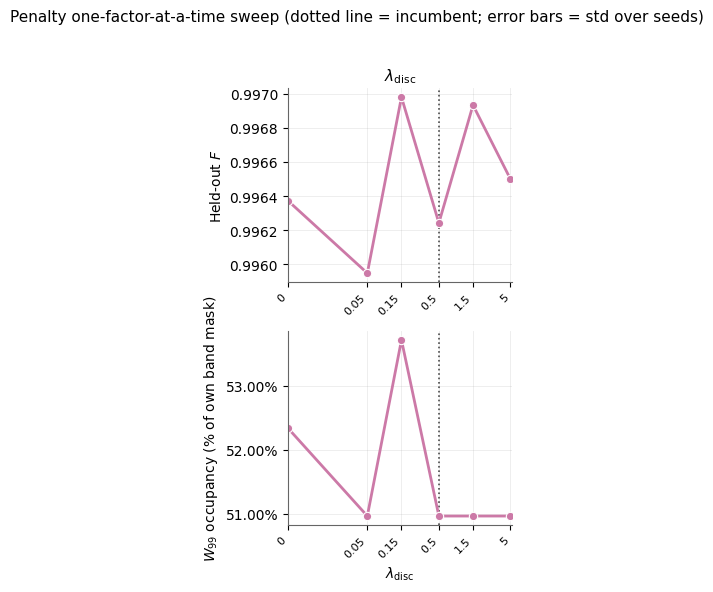

In [24]:
# The baseline rung was cached under the deriv ladder's hash (§7.3) and so
# carries swept="deriv"; relabel the copy so plot_ofat groups all 6 points
# into one "disc" panel instead of a 5-point "disc" panel plus a stray
# single-point "deriv" one.
disc_ladder = disc_null.copy()
disc_ladder.loc[disc_ladder["swept"] == "deriv", "swept"] = "disc"

fig = pv.plot_ofat(disc_ladder, save_path="figures/penalty_disc_null_ofat")

**Figure 4. The retired $\lambda_{\mathrm{disc}}$ ladder, drawn like every other axis.** Same
`pv.plot_ofat`, same incumbent dotted line, same error-bar convention (here trivially zero, this
data is single-seed). Held-out fidelity (top) wanders $0.995949 \to 0.996980$ non-monotonically
across a $0 \to 5.0$, hundredfold span: a range of $1.03\times10^{-3}$, exactly the
`floor_basin` figure quoted numerically in §7.4, now visible as noise rather than trend. The
occupied-width panel (bottom) is not perfectly flat either: it jitters by 2.8 points of the
transmon's own allowance, about two FFT bins (§14.2 puts one bin at 1.4 points), width-
quantization noise, not a $\lambda_{\mathrm{disc}}$ effect. Both panels are exactly the shape a
dynamically-null, basin-scrambling perturbation should produce: no trend, spread bounded by the
noise floor it defines.

### 13.2 The grid the current code actually produces

`analysis/penalty_sweep.py`'s `GRID_VALUES` no longer builds the $5\times5$ grid of §9: it was
trimmed post hoc to the low-$\lambda_{\mathrm{deriv}}$ $3\times3$ corner once §9.2 showed the
response was one-dimensional. `penalty_sweep_X_grid_deriv_boundary_3x3.csv` is what `--mode grid`
would emit today under the single-phase protocol; §9's figure never rendered it as its own
heatmap. The figure below goes one step further: it retrains that same 3x3 corner under the
new **two-phase** protocol (`analysis.penalty_sweep.TWO_PHASE`), on all 3 seeds rather than
just seed 42, so unlike the single-phase 3x3 table it is genuinely new, independently
measured data -- not a cache hit off the 5x5 grid.

Saved figures/penalty_grid_heatmap_3x3.png / .pdf


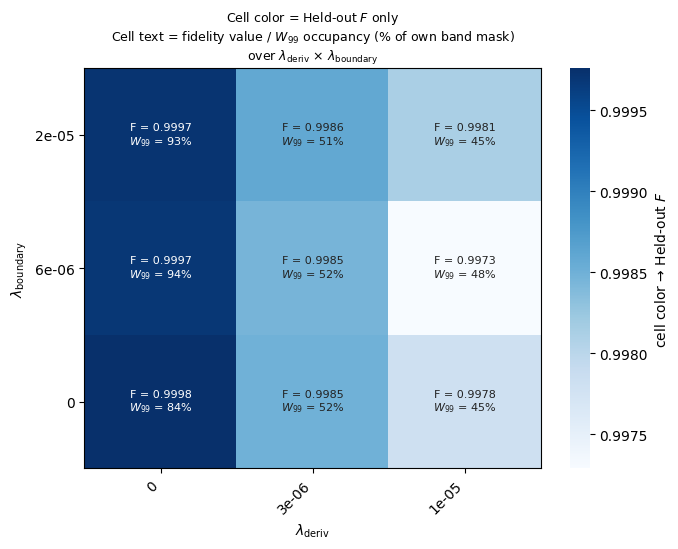

In [25]:
# grid3x3_2 (two-phase, 3-seed) was already loaded in the "Loading the sweep" cell above.
# pv.plot_grid_heatmap aggregates over seeds internally when a `seed` column is present,
# so this is a genuine 3-seed average with no extra code.
fig = pv.plot_grid_heatmap(grid3x3_2, "deriv", "boundary",
                           save_path="figures/penalty_grid_heatmap_3x3")

In [26]:
# grid3x3_2 is genuinely new data (two-phase, 3 seeds) -- unlike the RETIRED single-phase
# 3x3 corner, which was just the 5x5 grid's corner re-rendered (a cache hit, confirmed by
# byte-identical config_hash matches in an earlier version of this cell). Reconstruct that
# single-phase, single-seed baseline from `grid` (via the `corner` set already built above)
# and compare the two protocols on the same 9 (lambda_deriv, lambda_boundary) cells.
grid_3x3_1phase = grid[
    grid.apply(lambda r: (r.lambda_deriv, r.lambda_boundary) in corner, axis=1)
]

agg_2phase = pv.aggregate_seeds(grid3x3_2)
merged = agg_2phase.merge(
    grid_3x3_1phase[["lambda_deriv", "lambda_boundary", "F_ped_heldout_mean"]],
    on=["lambda_deriv", "lambda_boundary"], suffixes=("_2phase", "_1phase_1seed"),
)
merged["dF"] = merged["F_ped_heldout_mean_2phase"] - merged["F_ped_heldout_mean_1phase_1seed"]

print(f"{len(merged)}/9 cells matched by (lambda_deriv, lambda_boundary)")
print(f"protocol delta, 2-phase 3-seed mean minus 1-phase 1-seed: "
      f"mean {merged['dF'].mean():+.2e}, "
      f"range [{merged['dF'].min():+.2e}, {merged['dF'].max():+.2e}]")
print(f"within-2-phase seed spread (max std across the 9 cells): "
      f"{agg_2phase['F_ped_heldout_mean_std'].max():.2e}")

9/9 cells matched by (lambda_deriv, lambda_boundary)
protocol delta, 2-phase 3-seed mean minus 1-phase 1-seed: mean +7.87e-04, range [+1.09e-04, +1.88e-03]
within-2-phase seed spread (max std across the 9 cells): 9.88e-04


**Figure 5. The 3x3 corner, retrained under the two-phase protocol, 3-seed average.**
Same low-\(\lambda_{\mathrm{deriv}}\) block as the bottom-left of Figure 2, but every cell here
is a fresh two-phase pulse (cold-start \(\mathrm{trunc\_list}=[22,26]\) for 1000 iters, then
warm-started \(\mathrm{trunc\_list}=[26]\) for 1500 more), averaged over seeds 42, 43, 44 --
unlike the retired single-phase 3x3 corner (a cache hit off the 5x5 grid, confirmed byte-identical
in an earlier version of this section), this is genuinely new, independently measured data.
**Table 15** (the cell above) compares the two protocols on the same 9 cells: the 2-phase
3-seed mean differs from the historical 1-phase, 1-seed value by \(+7.87\times10^{-4}\) on
average (range \([+1.09, +18.8]\times10^{-4}\), always positive -- the two-phase protocol
never scored lower here), against a within-2-phase seed spread of up to \(9.88\times10^{-4}\).
The two figures are comparable in size: the protocol difference sits at, not clearly above,
the seed-to-seed noise floor -- the same "is this signal or floor" framing §7.4 applies
elsewhere in this document. It is consistent with a mild improvement, not established as one
at this seed count.

### 13.3 The OFAT ladder: single-phase vs two-phase

Same question as §13.2's Table 15, asked of the OFAT ladder instead of the grid corner:
`df` (single-phase, seeds 42-44) against `df2` (two-phase, seeds 42-46), matched by `label`.

In [27]:
# Cost: wall-clock per FRESH training run (train_time_s is NaN for cache-hit reused pulses).
df2 = load_sweep(f"penalty_sweep_{GATE}_ofat_two_phase")

for name, d in [("single-phase OFAT", df), ("single-phase grid", grid),
                ("two-phase OFAT", df2), ("two-phase grid", grid3x3_2)]:
    t = d["train_time_s"].dropna()
    print(f"{name:20s}: n_fresh={len(t):3d}  mean={t.mean():7.1f} s ({t.mean()/60:5.1f} min)  "
          f"min={t.min():7.1f}  max={t.max():7.1f}")

ratio_ofat = df2["train_time_s"].dropna().mean() / df["train_time_s"].dropna().mean()
ratio_grid = grid3x3_2["train_time_s"].dropna().mean() / grid["train_time_s"].dropna().mean()
print(f"\ntwo-phase / single-phase mean cost ratio: OFAT {ratio_ofat:.2f}x, grid {ratio_grid:.2f}x")

loaded tables/penalty_sweep_X_ofat_two_phase.csv: 75 rows, maxiter=[np.int64(2500)]
single-phase OFAT   : n_fresh= 45  mean= 1164.7 s ( 19.4 min)  min=  819.2  max= 2830.3
single-phase grid   : n_fresh= 25  mean=  956.4 s ( 15.9 min)  min=  806.0  max= 2738.3
two-phase OFAT      : n_fresh= 75  mean= 2120.0 s ( 35.3 min)  min= 1253.4  max= 7871.2
two-phase grid      : n_fresh= 27  mean= 1682.8 s ( 28.0 min)  min= 1334.2  max= 1931.8

two-phase / single-phase mean cost ratio: OFAT 1.82x, grid 1.76x


In [28]:
# Fidelity delta, matched by label (same method as Table 15 in §13.2), plus convergence.
g1 = df.groupby("label")["F_ped_heldout_mean"].agg(["mean", "std", "count"])
g2 = df2.groupby("label")["F_ped_heldout_mean"].agg(["mean", "std", "count"])
ofat_compare = g1.join(g2, lsuffix="_1phase", rsuffix="_2phase", how="inner")
ofat_compare["dF"] = ofat_compare["mean_2phase"] - ofat_compare["mean_1phase"]
ofat_compare = ofat_compare.sort_values("dF")

print(ofat_compare[["mean_1phase", "count_1phase", "mean_2phase", "count_2phase", "dF"]]
      .to_string(float_format=lambda x: f"{x:.6f}"))
print(f"\ndelta stats: mean={ofat_compare['dF'].mean():+.2e}  "
      f"range [{ofat_compare['dF'].min():+.2e}, {ofat_compare['dF'].max():+.2e}]")
print(f"configs scoring higher under two-phase: {(ofat_compare['dF']>0).sum()} of {len(ofat_compare)}")

n_conv_1phase = int((df["converged"] == True).sum())
n_conv_2phase = int((df2["converged"] == True).sum())
print(f"\nconvergence (scipy success flag; two-phase reflects phase 2 only):")
print(f"  single-phase: {n_conv_1phase}/{len(df)} converged, "
      f"all others hit the {int(df['iterations'].max())}-iteration cap")
print(f"  two-phase   : {n_conv_2phase}/{len(df2)} converged, "
      f"iterations range [{df2['iterations'].min():.0f}, {df2['iterations'].max():.0f}]")

                                                         mean_1phase  count_1phase  mean_2phase  count_2phase        dF
label                                                                                                                  
deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_ampmax=12     0.997508             3     0.997103             5 -0.000405
deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5               0.998760             3     0.998850             5  0.000090
deriv=1e-05_boundary=0_amp=8e-05_disc=0.5                   0.997750             3     0.997859             5  0.000108
deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5               0.999236             3     0.999357             5  0.000121
deriv=0_boundary=2e-05_amp=8e-05_disc=0.5                   0.999580             3     0.999757             5  0.000177
deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5               0.997753             3     0.998057             5  0.000304
deriv=1e-05_boundary=2e-05_amp=8e-05_dis

14 of the 15 OFAT configs score higher (mean held-out $F$) under two-phase; only
`deriv=1e-05_boundary=2e-05_..._ampmax=12` scores lower. Only the single largest positive
delta clears the $\sim\!10^{-3}$ noise floor established in §7.4 -- the rest, positive and
negative alike, sit inside it. Combined with the cost finding above (two-phase costs
\(\sim\)1.8x more per config): **switching to two-phase training is not currently justified
by this data** -- the fidelity gain it might be producing is not distinguishable from basin
noise at this seed count, and it is not cheap even if it were real. What it does provide is
the extra raw trials pooled into §15/Figure 6.

# 14. Caveats and outstanding work

### 14.1 Blocks the budget verdict

- **No run converged (45/45 capped), and spectral width had not stopped moving.** The fidelity
  ordering survived a 750-iteration continuation; the width did not settle. Over 750 further
  iterations the incumbent shed 8.3 points of its allowance and the recommendation gained 2.8.
  The recommendation stays 6.6 points inside the budget and the rejected family sits 9.1–27.8
  points outside it, so the margin now absorbs a drift of that size, but **neither continued
  configuration was one the budget rejects**, so the marginal loser's drift is unmeasured.
  **Re-running at higher `maxiter`, and continuing `deriv=0_boundary=6e-06` in particular, is the
  first outstanding item.** That configuration is the cavity-binding one of §10.3, so its drift
  would have to be measured on the cavity drive.
- **`occ99_frac` is still a soft, post-hoc budget, not a hardware spec.** It is an
  occupied-bandwidth figure at a stated power criterion, charged against the right allowance, but
  the genuinely hard spectral constraint remains the band-limit projection ($\pm27$ / $\pm33$ MHz),
  enforced by construction and never violated regardless of the weights.

### 14.2 Limits on precision

- **Three seeds (42, 43, 44), and that separates some claims but not all.** §13.1's disc-null
  ladder gives `floor_basin` $\approx 1.0\times10^{-3}$, confirmed independently by the direct
  across-seed spread (§7.4). At $n=3$, $\lambda_{\mathrm{deriv}}$'s effect clears that floor by
  roughly $12\times$; the recommendation's margin over incumbent does not ($t(2) = 2.9$ vs.
  the $4.30$ critical value). Separating $10^{-6}$ from $10^{-5}$ specifically would take on the
  order of a decade more seeds (§7.4).
- **Two of the four weights do nothing here.** $\lambda_{\mathrm{amp}}$ multiplies an
  identically-zero term; $\lambda_{\mathrm{disc}}$ contributes $\sim\!10^{-7}$ against an $O(1)$
  objective. Both are correctly implemented: they simply never activate as configured (§7.2).
- **$W_{99}$ is quantised to one FFT bin (0.909 MHz, i.e. 1.7 points of the cavity allowance or
  1.4 of the transmon), and its replicate-pair noise floor is two bins** (§7.3). Differences at
  that level between configurations are the metric's resolution and the optimizer's chaos, not a
  ranking, which is what the $\lambda = 0$ boundary row of Table 6 is showing.
- **The held-out set includes under-resolved truncations.** $n_c = 16, 18$ do not fully contain the
  $\alpha = \sqrt{3}$ cat ($\bar n = 3$), so they depress the held-out mean and dominate
  `robustness_spread` for *every* recipe. They are kept deliberately (a pulse that exploits the
  truncation wall fails there first), but the absolute value of `F_ped_heldout_mean` should not be
  quoted as "the gate fidelity". The per-truncation breakdown in the manifest JSON is the honest
  view.
- **The OFAT and grid ladders do not share cache entries where they should.**
  `BASELINE[x] * 3` and the grid's literal `3e-5` differ in the sixteenth digit, so two
  configurations were trained twice instead of reused. Rounding the OFAT rungs to a fixed precision
  would fix it, at the cost of invalidating those cache entries. Left as-is so the committed code
  reproduces the committed CSVs exactly, and §7.3 turns the accident into the noise floor.

### 14.3 Scope

- **Per-gate.** This is gate X. A recipe selected on X is a starting point for the other gates, not
  a validated setting for them.

# 15. Every trial, unaggregated: searching for the single best run

Sections 7 and 10 above answer "which config is best on average" -- every number there is a
seed mean, and §7.4's whole point is that seed-to-seed noise (\(\sim\!10^{-3}\)) has to be
respected before one config is called better than its neighbours. This section asks a
different question: forget averaging, what is the single best INDIVIDUAL run this campaign
has produced? A deployed pulse is one specific trained waveform, not a mean, so it is worth
knowing what the best individual draw looked like, and by how much (if at all) it beats
§10.4's mean-based recommendation.

This is deliberately NOT a competing recommendation. Picking the best of many trials is
optimistic by construction -- the more trials pooled, the luckier the winner can get purely by
chance, independent of whether its config is actually better. Read its margin over §10.4's
pick against §7.4's noise floor before drawing any conclusion from it.

`all_trials` pools every trial ever run in this campaign, across every protocol: the
single-phase OFAT ladder (`df`, seeds 42-44), the single-phase 5x5 grid (`grid`, seed 42),
the two-phase 3x3 corner (`grid3x3_2`, seeds 42-44), and the two-phase OFAT ladder (`df2`,
seeds 42-46) loaded below. `disc_null` stays excluded, same rule as `combined` above (§13's
opening note): it is a calibrated null, not a ranking candidate.

In [29]:
df2 = load_sweep(f"penalty_sweep_{GATE}_ofat_two_phase")

all_trials = pd.concat(
    [df, grid, grid3x3_2, df2], ignore_index=True
).drop_duplicates(subset=["config_hash", "seed"])

print(f"all_trials: {len(all_trials)} individual trials, "
      f"{all_trials.config_hash.nunique()} distinct trained pulses, "
      f"{all_trials.label.nunique()} distinct recipes, "
      f"protocols={sorted(all_trials.get('protocol', pd.Series(dtype=str)).fillna('single_phase').unique())}")

loaded tables/penalty_sweep_X_ofat_two_phase.csv: 75 rows, maxiter=[np.int64(2500)]
all_trials: 150 individual trials, 150 distinct trained pulses, 31 distinct recipes, protocols=['single_phase', 'two_phase']


Saved figures/penalty_all_trials.png / .pdf


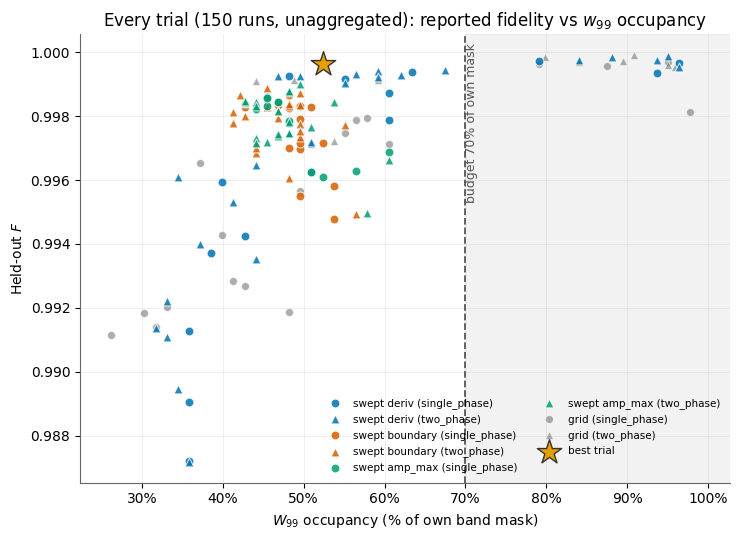

In [30]:
fig, best = pv.plot_all_trials(all_trials, save_path="figures/penalty_all_trials",
                               max_cost=COST_BUDGET)

**Figure 6. Every individual trial, no seed-averaging.** One marker per (config, seed) run;
circles are single-phase trials, triangles two-phase. Color follows the same swept-axis
convention as Figure 3; grid trials (both protocols) get the neutral grey. The shaded region
and dashed line are the same 70% budget as Figure 3. The gold star is the single best
budget-feasible trial by held-out fidelity (`find_best_trial`, printed below) -- NOT the
seed-mean recommendation of Figure 3/§10.4, see this section's opening caveat about reading
too much into it.

In [31]:
best = pv.find_best_trial(all_trials, max_cost=COST_BUDGET)
print(f"best individual trial (budget-feasible, highest held-out F):")
print(f"  label     : {best['label']}")
print(f"  seed      : {best['seed']}")
print(f"  protocol  : {best.get('protocol', 'single_phase')}")
print(f"  F_held    : {best['F']:.6f}")
print(f"  {COST_METRIC}     : {best['cost']:.1%} of the binding drive's own mask")
print(f"  config_hash: {best['config_hash']}")

print(f"\nvs. Figure 3's seed-mean recommendation:")
print(f"  label     : {rec['label']}")
print(f"  F_held    : {rec['F']:.6f}  (mean over {int(rec.get('n_seeds', 1))} seed(s))")
print(f"  margin    : best trial exceeds the recommendation's mean by "
      f"{best['F'] - rec['F']:+.2e} -- compare against §7.4's noise floor "
      f"(\N{APPROXIMATELY EQUAL TO}1e-3) before reading this as a real gap.")

best individual trial (budget-feasible, highest held-out F):
  label     : deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5
  seed      : 43
  protocol  : two_phase
  F_held    : 0.999621
  occ99_frac     : 52.3% of the binding drive's own mask
  config_hash: 4a0a82f22f08357c

vs. Figure 3's seed-mean recommendation:
  label     : deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5
  F_held    : 0.999236  (mean over 3 seed(s))
  margin    : best trial exceeds the recommendation's mean by +3.85e-04 -- compare against §7.4's noise floor (≅1e-3) before reading this as a real gap.


**On reading the best-trial result.** A single lucky seed is not evidence that its config is
the true optimum -- it is evidence that, among the trials actually run, this is the best one
observed. If the margin over §10.4's recommendation is smaller than §7.4's \(\sim\!10^{-3}\)
noise floor, it is noise, exactly like every other sub-floor comparison flagged elsewhere in
this document (§7.3, §7.4, §13.1). If it is larger, that is a config/seed combination worth
a dedicated replication run before it is trusted, not a reason to deploy it directly -- the
whole point of §7.4 was that single-seed conclusions are exactly the failure mode this
campaign was extended to guard against.